# 3D Computer Vision: Point Clouds, NeRF & Gaussian Splatting

This notebook covers the full 3D computer vision pipeline, from classical geometry to modern neural representations:

- **Classical 3D**: Stereo matching, Structure from Motion (SfM), SLAM (ORB-SLAM3, LSD-SLAM), and monocular depth estimation
- **Point Clouds**: PLY/PCD formats, voxelization, Farthest Point Sampling (FPS), ball query
- **PointNet family**: PointNet (permutation invariance via max pooling), PointNet++ (hierarchical), DGCNN (dynamic graph)
- **Neural Radiance Fields (NeRF)**: Volume rendering, positional encoding, hierarchical sampling, and key variants
- **3D Gaussian Splatting**: Explicit Gaussian representation, differentiable rasterization, real-time rendering
- **BEV Perception & Implicit Neural Representations**: Bird's Eye View for autonomous driving, occupancy networks

## Classical 3D Computer Vision

### Stereo Matching
Stereo vision reconstructs depth from two cameras separated by a **baseline** B. Key concepts:
- **Epipolar geometry**: corresponding points in left/right images lie on conjugate epipolar lines reduces 2D search to 1D
- **Rectification**: warp images so epipolar lines are horizontal scan lines
- **Disparity map**: d = pixel shift between matching points in left/right images
- **Depth formula**: `Z = f * B / d` where f = focal length (pixels), B = baseline (meters), d = disparity (pixels)

### Structure from Motion (SfM)
Reconstructs 3D structure from a collection of 2D images:
1. **Feature extraction**: SIFT/SuperPoint keypoints per image
2. **Feature matching**: FLANN/mutual nearest-neighbor across image pairs
3. **Essential matrix**: E = [t]×R encodes relative pose; decomposed via SVD
4. **Triangulation**: back-project matched rays to 3D points
5. **Bundle adjustment**: joint optimization of camera poses + 3D points (Ceres/g2o)

### SLAM Methods

| Method | Type | Features | Loop Closure | Notes |
|--------|------|----------|--------------|-------|
| ORB-SLAM3 | Feature-based | ORB | DBoW2 vocabulary tree | Multi-map, IMU fusion |
| LSD-SLAM | Direct (semi-dense) | Photometric error | Sim(3) pose graph | No feature extraction needed |
| DSO | Direct (sparse) | Photometric, sparse | None | Windowed optimization |
| ElasticFusion | RGB-D | Surfel map | Appearance + geometry | Dense reconstruction |
| NICE-SLAM | Neural | Neural occupancy | Implicit | NeRF-based SLAM |

### Monocular Depth Estimation
- **MiDaS**: multi-dataset training with scale-invariant loss; affine-invariant depth
- **ZoeDepth**: metric depth by adding domain-specific heads on top of MiDaS
- **Depth Anything v1/v2**: DINOv2 backbone, large-scale unlabeled data, strong zero-shot generalization

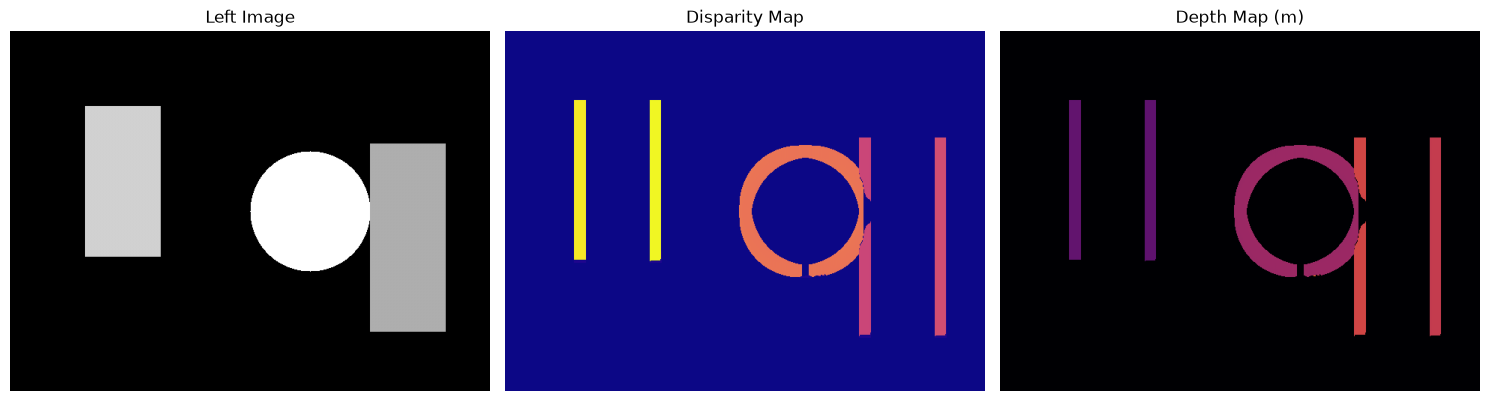

Disparity range: [-1.0, 31.2]
Depth range (non-zero): [2.69m, 7.55m]


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Synthetic stereo pair (left and right shifted)
np.random.seed(42)
height, width = 480, 640
# Create a synthetic scene with depth variation
scene = np.zeros((height, width), dtype=np.uint8)
# Add some geometric shapes at different depths
cv2.rectangle(scene, (100, 100), (200, 300), 180, -1)
cv2.circle(scene, (400, 240), 80, 220, -1)
cv2.rectangle(scene, (480, 150), (580, 400), 150, -1)

# Simulate stereo pair with horizontal disparity
disparity_gt = np.zeros((height, width), dtype=np.float32)
disparity_gt[100:300, 100:200] = 30  # close object
disparity_gt[160:320, 320:480] = 20  # medium object
disparity_gt[150:400, 480:580] = 15  # far object

left_img = scene.copy()
right_img = np.zeros_like(scene)

# Shift pixels by disparity to create right image
for y in range(height):
    for x in range(width):
        d = int(disparity_gt[y, x])
        if x - d >= 0:
            right_img[y, x-d] = left_img[y, x]

# StereoBM disparity computation
stereo = cv2.StereoBM_create(numDisparities=64, blockSize=15)
disparity = stereo.compute(left_img, right_img).astype(np.float32) / 16.0

# Depth from disparity: Z = f*B/d (assume f=700, B=0.12m)
focal_length = 700
baseline = 0.12
with np.errstate(divide='ignore', invalid='ignore'):
    depth = np.where(disparity > 0, focal_length * baseline / disparity, 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(left_img, cmap='gray'); axes[0].set_title('Left Image'); axes[0].axis('off')
axes[1].imshow(disparity, cmap='plasma'); axes[1].set_title('Disparity Map'); axes[1].axis('off')
axes[2].imshow(depth, cmap='inferno', vmax=10); axes[2].set_title('Depth Map (m)'); axes[2].axis('off')
plt.tight_layout(); plt.show()
print(f"Disparity range: [{disparity.min():.1f}, {disparity.max():.1f}]")
print(f"Depth range (non-zero): [{depth[depth>0].min():.2f}m, {depth[depth>0].max():.2f}m]")

## Point Clouds

A **point cloud** is an unordered set of 3D points {x_i ∈ ℝ³}, optionally with per-point attributes (color, normal, intensity).

### File Formats
- **PLY** (Polygon File Format): ASCII or binary; stores vertices, faces, per-point properties
- **PCD** (Point Cloud Data): PCL's native format; supports compressed binary; widely used in robotics

### Voxelization
Divide 3D space into a regular grid of voxels (volumetric pixels):
1. Choose voxel size `v`
2. Assign index `(i,j,k) = floor(x/v, y/v, z/v)` to each point
3. Represent each occupied voxel by its center or mean of contained points
- **Advantage**: regular structure enables 3D convolutions (VoxNet, SECOND)
- **Disadvantage**: memory O(N³) sparse representations (SparseConvNet) mitigate this

### Farthest Point Sampling (FPS)
Iteratively select points maximally distant from the current selected set:
1. Initialize: choose a random seed point
2. For each iteration: select the point with maximum **minimum distance** to already-selected points
3. Repeat until N samples selected

FPS provides a more **uniform coverage** of the point cloud than random sampling.

### Ball Query
Find all points within radius `r` of a query point `p`:
- Returns a fixed-size neighborhood (pad/truncate to K points)
- Used in PointNet++ set abstraction to group local regions

### Sampling Method Comparison

| Method | Uniformity | Speed | Memory | Use Case |
|--------|-----------|-------|--------|----------|
| Random | Low | O(1) | O(1) | Quick prototyping |
| FPS | High | O(N·k) | O(N) | PointNet++, learning |
| Grid (voxel) | Medium | O(N) | O(grid) | Autonomous driving |
| Poisson disk | Very high | O(N log N) | O(N) | 3DGS initialization |

Original points: 2000
After FPS (200 samples): 200
After voxelization (0.5m): 306 voxels


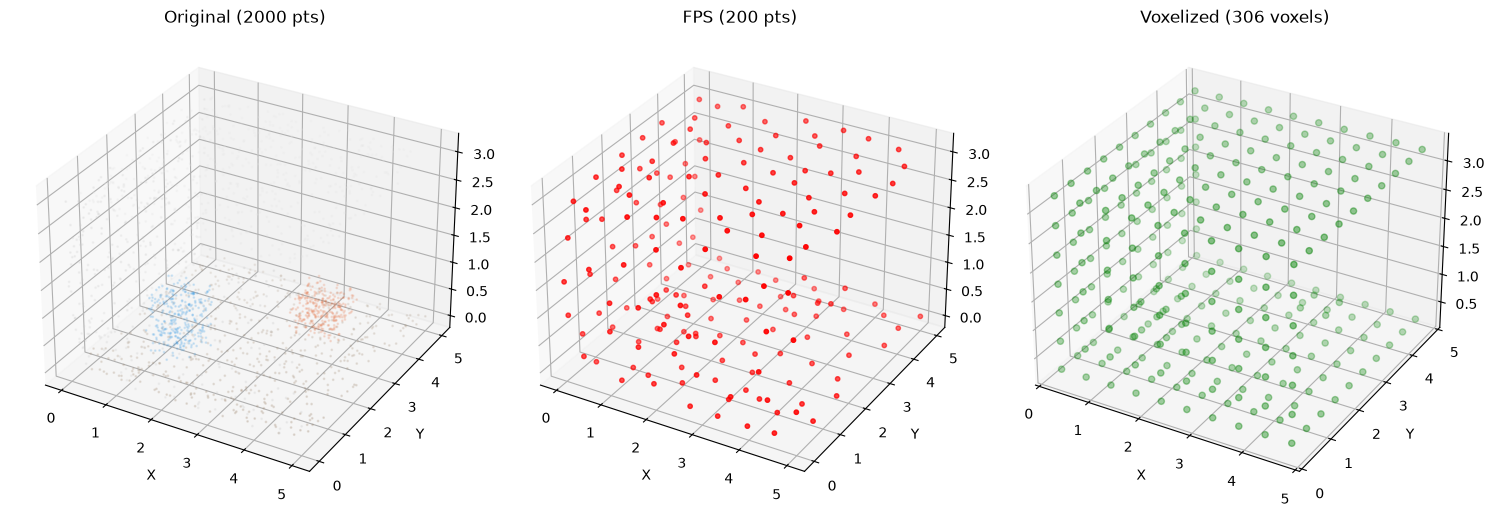

In [2]:
# pip install open3d
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Generate synthetic point cloud (simulate a room)
np.random.seed(42)
n_points = 2000

# Floor
floor_pts = np.random.uniform([0,0,0], [5,5,0.1], (500, 3))
# Walls
wall1 = np.column_stack([np.zeros(200), np.random.uniform(0,5,200), np.random.uniform(0,3,200)])
wall2 = np.column_stack([np.random.uniform(0,5,200), np.zeros(200), np.random.uniform(0,3,200)])
# Objects (boxes)
box1 = np.random.uniform([1,1,0.1], [2,2,1.2], (300, 3))
box2 = np.random.uniform([3,3,0.1], [4,4,0.8], (300, 3))
# Ceiling
ceiling = np.random.uniform([0,0,3], [5,5,3.1], (500, 3))

points = np.vstack([floor_pts, wall1, wall2, box1, box2, ceiling])
colors = np.vstack([
    np.tile([0.6, 0.5, 0.4], (500,1)),   # floor: brown
    np.tile([0.8, 0.8, 0.8], (200,1)),   # walls: gray
    np.tile([0.8, 0.8, 0.8], (200,1)),
    np.tile([0.2, 0.6, 0.9], (300,1)),   # box1: blue
    np.tile([0.9, 0.4, 0.2], (300,1)),   # box2: orange
    np.tile([0.9, 0.9, 0.9], (500,1)),   # ceiling: white
])

# Farthest Point Sampling
def farthest_point_sampling(points, n_samples):
    """FPS: iteratively select the point farthest from the current selected set."""
    N = len(points)
    selected = np.zeros(n_samples, dtype=int)
    distances = np.full(N, np.inf)
    selected[0] = np.random.randint(N)
    for i in range(1, n_samples):
        last = points[selected[i-1]]
        dist = np.sum((points - last)**2, axis=1)
        distances = np.minimum(distances, dist)
        selected[i] = np.argmax(distances)
    return selected

fps_indices = farthest_point_sampling(points, 200)
fps_points = points[fps_indices]

# Voxelization
def voxelize(points, voxel_size=0.5):
    """Assign each point to a voxel, return voxel centers."""
    voxel_indices = np.floor(points / voxel_size).astype(int)
    unique_voxels = np.unique(voxel_indices, axis=0)
    voxel_centers = (unique_voxels + 0.5) * voxel_size
    return voxel_centers, unique_voxels

voxel_centers, voxel_indices = voxelize(points, voxel_size=0.5)
print(f"Original points: {len(points)}")
print(f"After FPS (200 samples): {len(fps_points)}")
print(f"After voxelization (0.5m): {len(voxel_centers)} voxels")

fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(points[:,0], points[:,1], points[:,2], c=colors, s=1, alpha=0.5)
ax1.set_title(f'Original ({len(points)} pts)'); ax1.set_xlabel('X'); ax1.set_ylabel('Y')

ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(fps_points[:,0], fps_points[:,1], fps_points[:,2], c='red', s=10)
ax2.set_title(f'FPS ({len(fps_points)} pts)'); ax2.set_xlabel('X'); ax2.set_ylabel('Y')

ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(voxel_centers[:,0], voxel_centers[:,1], voxel_centers[:,2], c='green', s=20, alpha=0.7)
ax3.set_title(f'Voxelized ({len(voxel_centers)} voxels)'); ax3.set_xlabel('X'); ax3.set_ylabel('Y')
plt.tight_layout(); plt.show()

## PointNet

PointNet (Qi et al., 2017) directly processes raw point clouds with a **symmetric function** for permutation invariance.

### Core Formula
$$f(\{x_1,...,x_n\}) = \gamma\left(MAX\left(\{h(x_i)\}\right)\right)$$

- $h$: shared MLP applied independently to each point (weight sharing)
- $MAX$: element-wise maximum over all points symmetric → permutation invariant
- $\gamma$: downstream MLP for classification/segmentation

### T-Net: Spatial Transformer
A **mini-PointNet** that predicts a transformation matrix to canonicalize input:
- **Input T-Net**: predicts 3×3 matrix to align input point cloud
- **Feature T-Net**: predicts 64×64 matrix to align feature space
- Regularized with orthogonality loss: $L_{reg} = \|AA^T - I\|^2_F$

### Architecture (Classification)

```
Input (N×3) → Input T-Net (3×3) → MLP(64,64) → Feature T-Net (64×64) → MLP(64,128,1024)
→ Max Pool → Global Feature (1024) → MLP(512,256,K) → Output (K classes)
```

### Key Properties
1. **Permutation invariance**: max pooling ensures same output regardless of point ordering
2. **Transformation invariance**: T-Net aligns inputs to a canonical space
3. **Theoretical analysis**: critical points (sparse subset that determines output) + upper bound shapes (largest cloud with same max pool)

### Limitations
- No **local context**: each point processed independently before global pooling
- Fixed **resolution**: no hierarchical multi-scale feature extraction

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TNet(nn.Module):
    """T-Net: predicts a k×k transformation matrix via mini-PointNet."""
    def __init__(self, k=3):
        super().__init__()
        self.k = k
        self.conv1 = nn.Conv1d(k, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 1024, 1)
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, k*k)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)
        # Initialize as identity
        nn.init.zeros_(self.fc3.weight)
        nn.init.zeros_(self.fc3.bias)
        
    def forward(self, x):
        B, k, N = x.shape
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = x.max(dim=2)[0]  # Global max pooling: (B, 1024)
        x = F.relu(self.bn4(self.fc1(x)))
        x = F.relu(self.bn5(self.fc2(x)))
        x = self.fc3(x)  # (B, k*k)
        # Add identity matrix
        identity = torch.eye(self.k, device=x.device).flatten().unsqueeze(0).expand(B, -1)
        x = x + identity
        return x.view(B, self.k, self.k)


class PointNetEncoder(nn.Module):
    """PointNet encoder: input transform → MLP → feature transform → MLP → max pool."""
    def __init__(self, global_feat=True, feature_transform=True):
        super().__init__()
        self.global_feat = global_feat
        self.feature_transform = feature_transform
        
        self.tnet_input = TNet(k=3)
        self.conv1 = nn.Conv1d(3, 64, 1)
        self.conv2 = nn.Conv1d(64, 64, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(64)
        
        if feature_transform:
            self.tnet_feat = TNet(k=64)
        
        self.conv3 = nn.Conv1d(64, 64, 1)
        self.conv4 = nn.Conv1d(64, 128, 1)
        self.conv5 = nn.Conv1d(128, 1024, 1)
        self.bn3 = nn.BatchNorm1d(64)
        self.bn4 = nn.BatchNorm1d(128)
        self.bn5 = nn.BatchNorm1d(1024)
        
    def forward(self, x):
        B, N, _ = x.shape
        x = x.transpose(2, 1)  # (B, 3, N)
        
        # Input transformation
        T_input = self.tnet_input(x)          # (B, 3, 3)
        x = torch.bmm(T_input, x)            # (B, 3, N) aligned point cloud
        
        # MLP: 3 → 64 → 64
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        
        # Feature transformation
        T_feat = None
        if self.feature_transform:
            T_feat = self.tnet_feat(x)        # (B, 64, 64)
            x = torch.bmm(T_feat, x)          # (B, 64, N)
        
        local_feat = x  # Save for segmentation
        
        # MLP: 64 → 64 → 128 → 1024
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.bn5(self.conv5(x))           # (B, 1024, N)
        
        # Global max pooling
        global_feat = x.max(dim=2)[0]        # (B, 1024)
        
        if self.global_feat:
            return global_feat, T_feat
        else:
            # For segmentation: concatenate global + local
            global_feat_exp = global_feat.unsqueeze(2).expand(-1, -1, N)
            return torch.cat([local_feat, global_feat_exp], dim=1), T_feat  # (B, 1088, N)


class PointNetClassifier(nn.Module):
    """PointNet for classification: encoder → 3-layer MLP → softmax."""
    def __init__(self, num_classes=40):
        super().__init__()
        self.encoder = PointNetEncoder(global_feat=True)
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)
        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(p=0.3)
        
    def forward(self, x):
        feat, T_feat = self.encoder(x)       # (B, 1024)
        x = F.relu(self.bn1(self.fc1(feat)))
        x = F.relu(self.bn2(self.dropout(self.fc2(x))))
        x = self.fc3(x)
        return F.log_softmax(x, dim=1), T_feat


class PointNetSegmentation(nn.Module):
    """PointNet for part segmentation: encoder (local+global) → per-point MLP."""
    def __init__(self, num_classes=50):
        super().__init__()
        self.encoder = PointNetEncoder(global_feat=False)
        self.conv1 = nn.Conv1d(1088, 512, 1)
        self.conv2 = nn.Conv1d(512, 256, 1)
        self.conv3 = nn.Conv1d(256, 128, 1)
        self.conv4 = nn.Conv1d(128, num_classes, 1)
        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.bn3 = nn.BatchNorm1d(128)
        
    def forward(self, x):
        B, N, _ = x.shape
        feat, T_feat = self.encoder(x)       # (B, 1088, N)
        x = F.relu(self.bn1(self.conv1(feat)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.conv4(x)                    # (B, num_classes, N)
        x = x.transpose(2, 1)               # (B, N, num_classes)
        return F.log_softmax(x, dim=-1), T_feat


# Test both models
B, N = 8, 1024  # batch=8, 1024 points

# Classification
clf = PointNetClassifier(num_classes=40)
x = torch.randn(B, N, 3)
out, T_feat = clf(x)
print(f"Classification Input: {x.shape}, Output: {out.shape}")
print(f"  T-Net (64×64): {T_feat.shape}")
params = sum(p.numel() for p in clf.parameters())
print(f"  Parameters: {params/1e6:.2f}M")

# Segmentation
seg = PointNetSegmentation(num_classes=50)
x = torch.randn(B, N, 3)
out, _ = seg(x)
print(f"\nSegmentation Input: {x.shape}, Output: {out.shape}")
params = sum(p.numel() for p in seg.parameters())
print(f"  Parameters: {params/1e6:.2f}M")

# Regularization loss for T-Net (force orthogonality: A*A^T ≈ I)
def feature_transform_regularizer(T):
    B, k, _ = T.shape
    I = torch.eye(k, device=T.device).unsqueeze(0)
    loss = torch.mean(torch.norm(torch.bmm(T, T.transpose(2,1)) - I, dim=(1,2)))
    return loss

reg_loss = feature_transform_regularizer(T_feat)
print(f"\nT-Net regularization loss: {reg_loss.item():.4f} (should be ~0 after training)")

Classification Input: torch.Size([8, 1024, 3]), Output: torch.Size([8, 40])
  T-Net (64×64): torch.Size([8, 64, 64])
  Parameters: 3.48M



Segmentation Input: torch.Size([8, 1024, 3]), Output: torch.Size([8, 1024, 50])
  Parameters: 3.54M

T-Net regularization loss: 0.0000 (should be ~0 after training)


## PointNet++ and DGCNN

### PointNet++: Hierarchical Point Set Learning
PointNet++ (Qi et al., 2017b) addresses PointNet's lack of local context via **hierarchical grouping**:

**Set Abstraction (SA) Layer**:
1. **FPS**: sample M centroids from N input points
2. **Ball query**: for each centroid, find all points within radius r (up to K points)
3. **PointNet**: apply mini-PointNet to each local group → local feature per centroid

**Multi-Scale Grouping (MSG)**:
- Use **multiple ball radii** [r₁, r₂, r₃] simultaneously
- Concatenate features from all scales → robust to density variation

**Feature Propagation (upsampling)**:
- Inverse distance weighted interpolation from sparse to dense points
- Skip connections from encoder → concatenated with interpolated features
- Used for segmentation tasks

### DGCNN: Dynamic Graph CNN
DGCNN (Wang et al., 2019) captures local geometric structure via a **dynamic graph** in feature space.

**EdgeConv Operation**:
$$h_\Theta(x_i, x_j - x_i) \quad \forall j \in \mathcal{N}(i)$$
- For each point $x_i$, find its k nearest neighbors $x_j$ in **feature space**
- Construct edge feature: $[x_i \| (x_j - x_i)]$ central point + relative position
- Apply shared MLP → aggregate via max pooling over neighbors

**Key insight**: the graph is **recomputed at each layer** in the current feature space (not fixed input space), enabling adaptive receptive fields.

### VoteNet: 3D Object Detection via Hough Voting
- Each seed point uses a learned offset to **vote for the object center** it likely belongs to
- Votes are clustered (ball query grouping) → object proposals
- Each cluster → bounding box prediction via PointNet

### Comparison Table

| Model | Local Context | Graph | Hierarchy | Best For |
|-------|--------------|-------|-----------|----------|
| PointNet | None | None | None | Fast baseline, robust |
| PointNet++ | Ball query | None | Yes (SA layers) | Classification, segmentation |
| DGCNN | k-NN (feature space) | Dynamic | None | Classification, flow |
| VoteNet | PointNet++ backbone | None | Yes | 3D object detection |
| KPConv | Kernel points | None | Yes | Large-scale segmentation |

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def knn(x, k):
    """Find k nearest neighbors in feature space. x: (B, C, N)"""
    # Pairwise distance matrix
    x_t = x.transpose(2, 1)               # (B, N, C)
    inner = -2 * torch.bmm(x_t, x)       # (B, N, N)
    xx = (x**2).sum(dim=1, keepdim=True)  # (B, 1, N)
    pairwise_dist = xx + xx.transpose(2,1) + inner  # (B, N, N)
    # k nearest (smallest distance, excluding self)
    idx = pairwise_dist.topk(k=k, dim=-1, largest=False)[1]  # (B, N, k)
    return idx


def get_graph_feature(x, k=20):
    """
    Construct edge features: [x_i || (x_j - x_i)] for each neighbor j.
    x: (B, C, N) → output: (B, 2C, N, k)
    """
    B, C, N = x.shape
    idx = knn(x, k=k)                    # (B, N, k)
    
    # Gather neighbor features
    idx_base = torch.arange(0, B, device=x.device).view(-1,1,1) * N
    idx_flat = (idx + idx_base).view(B, -1)  # (B, N*k)
    
    x_flat = x.transpose(2,1).contiguous().view(B*N, C)  # (B*N, C)
    neighbors = x_flat[idx_flat.view(-1), :].view(B, N, k, C)  # (B, N, k, C)
    neighbors = neighbors.permute(0, 3, 1, 2)  # (B, C, N, k)
    
    x_central = x.unsqueeze(3).expand(-1, -1, -1, k)  # (B, C, N, k)
    
    # Edge feature: [central || (neighbor - central)]
    edge_feat = torch.cat([x_central, neighbors - x_central], dim=1)  # (B, 2C, N, k)
    return edge_feat


class EdgeConv(nn.Module):
    """DGCNN EdgeConv layer: aggregate k-NN edge features via max pooling."""
    def __init__(self, in_channels, out_channels, k=20):
        super().__init__()
        self.k = k
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels * 2, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2)
        )
    
    def forward(self, x):
        edge_feat = get_graph_feature(x, k=self.k)  # (B, 2C, N, k)
        x = self.conv(edge_feat)                     # (B, out_C, N, k)
        x = x.max(dim=-1)[0]                        # (B, out_C, N) aggregate over neighbors
        return x


class DGCNN(nn.Module):
    """Dynamic Graph CNN for point cloud classification."""
    def __init__(self, num_classes=40, k=20, emb_dims=1024):
        super().__init__()
        self.k = k
        self.ec1 = EdgeConv(3, 64, k)
        self.ec2 = EdgeConv(64, 64, k)
        self.ec3 = EdgeConv(64, 128, k)
        self.ec4 = EdgeConv(128, 256, k)
        
        self.conv = nn.Sequential(
            nn.Conv1d(64+64+128+256, emb_dims, 1, bias=False),
            nn.BatchNorm1d(emb_dims),
            nn.LeakyReLU(0.2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(emb_dims*2, 512), nn.BatchNorm1d(512), nn.LeakyReLU(0.2), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        # x: (B, N, 3)
        x = x.transpose(2, 1)  # (B, 3, N)
        x1 = self.ec1(x)   # (B, 64, N)
        x2 = self.ec2(x1)  # (B, 64, N)
        x3 = self.ec3(x2)  # (B, 128, N)
        x4 = self.ec4(x3)  # (B, 256, N)
        
        x_cat = torch.cat([x1, x2, x3, x4], dim=1)  # (B, 512, N)
        x_emb = self.conv(x_cat)                     # (B, 1024, N)
        
        # Global descriptor: max + mean pooling
        x_max = x_emb.max(dim=2)[0]     # (B, 1024)
        x_mean = x_emb.mean(dim=2)      # (B, 1024)
        x_global = torch.cat([x_max, x_mean], dim=1)  # (B, 2048)
        
        return self.classifier(x_global)


# Test DGCNN
dgcnn = DGCNN(num_classes=40, k=10)  # k=10 for speed in test
x = torch.randn(4, 256, 3)  # 4 clouds of 256 points
out = dgcnn(x)
print(f"DGCNN Input: {x.shape}, Output: {out.shape}")
params = sum(p.numel() for p in dgcnn.parameters())
print(f"Parameters: {params/1e6:.2f}M")

DGCNN Input: torch.Size([4, 256, 3]), Output: torch.Size([4, 40])
Parameters: 1.81M


## Neural Radiance Fields (NeRF)

NeRF (Mildenhall et al., 2020) represents a scene as a **continuous volumetric function** and renders novel views via differentiable volume rendering.

### Volume Rendering Equation
$$C(\mathbf{r}) = \int_{t_n}^{t_f} T(t)\,\sigma(\mathbf{r}(t))\,\mathbf{c}(\mathbf{r}(t),\mathbf{d})\,dt$$

where the **transmittance** (probability of ray reaching $t$ without hitting anything):
$$T(t) = \exp\!\left(-\int_{t_n}^{t} \sigma(\mathbf{r}(s))\,ds\right)$$

### Discrete Approximation
$$\hat{C}(\mathbf{r}) = \sum_{i=1}^{N} T_i\,(1-e^{-\sigma_i\delta_i})\,\mathbf{c}_i$$

where $T_i = \exp(-\sum_{j<i}\sigma_j\delta_j)$, $\delta_i = t_{i+1} - t_i$ is the step size.

### Positional Encoding
Raw coordinates are poor inputs for MLPs. NeRF maps inputs to a higher frequency space:
$$\gamma(p) = \left(\sin(2^0\pi p),\,\cos(2^0\pi p),\,\ldots,\,\sin(2^{L-1}\pi p),\,\cos(2^{L-1}\pi p)\right)$$
- $L=10$ for positions (xyz), $L=4$ for directions (θ,φ)
- Enables the MLP to represent high-frequency scene details

### Hierarchical Sampling
1. **Coarse network**: stratified random sampling along ray (N_c=64 samples)
2. **Fine network**: importance sampling using coarse density as PDF (N_f=128 additional samples)
3. Both outputs combined for final rendering

### NeRF Variants

| Model | Key Innovation | Speed | Scale |
|-------|---------------|-------|-------|
| Vanilla NeRF | Volume rendering + PE | ~30h train, ~30s/img | Object-level |
| NeRF-W | Per-image appearance embeddings | Similar | Unconstrained photos |
| Mip-NeRF | Cone casting + IPE (anti-aliasing) | Similar | Multi-scale |
| NeRF++ | Foreground + inverted sphere background | Similar | Unbounded scenes |
| Block-NeRF | City-scale, multiple NeRFs | Similar | City-scale |
| Instant-NGP | Hash encoding | **~5min train, real-time** | Object-level |
| TensoRF | Tensor decomposition | Fast | Object-level |

### Instant-NGP Hash Encoding
Multi-resolution hash table: for each of $L$ resolution levels, hash 3D grid cell index to a feature vector. Bilinear interpolation + concatenate all levels:
$$E(\mathbf{x}) = [e_1(\mathbf{x}), e_2(\mathbf{x}), \ldots, e_L(\mathbf{x})]$$
Achieves **~1000× speedup** with tiny MLP on top of hash features.

NeRF parameters: 0.16M


rgb: torch.Size([1, 64, 64, 3]), sigma: torch.Size([1, 64, 64, 1])
Rendered: torch.Size([1, 64, 3]), Weights: torch.Size([1, 64, 64])
Weight sum (should ≤1): 1.0000


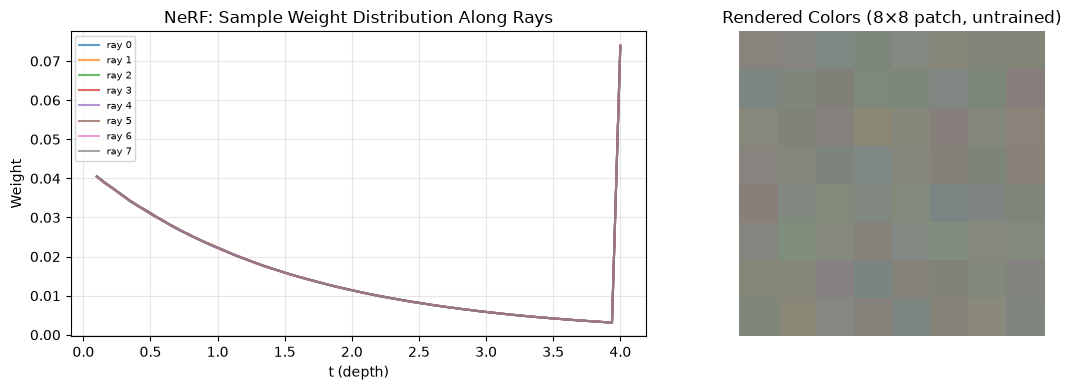

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

class PositionalEncoding(nn.Module):
    """Fourier positional encoding for NeRF inputs."""
    def __init__(self, L=10):
        super().__init__()
        self.L = L
        self.out_dim_per_input = 2 * L  # sin + cos for each frequency
    
    def forward(self, x):
        """x: (..., D) → (..., D + D*2*L) (includes original coords)"""
        freqs = 2.0 ** torch.arange(self.L, device=x.device, dtype=x.dtype) * np.pi
        # x: (..., D), freqs: (L,)
        x_enc = x.unsqueeze(-1) * freqs  # (..., D, L)
        x_enc = torch.cat([torch.sin(x_enc), torch.cos(x_enc)], dim=-1)  # (..., D, 2L)
        x_enc = x_enc.flatten(-2)         # (..., D*2L)
        return torch.cat([x, x_enc], dim=-1)  # (..., D + D*2L)


class NeRF(nn.Module):
    """
    NeRF MLP: 5D (position + direction) → (RGB, density σ).
    Architecture from the original paper (8 layers, skip at layer 4).
    """
    def __init__(self, L_pos=10, L_dir=4, hidden=256):
        super().__init__()
        self.pos_enc = PositionalEncoding(L=L_pos)
        self.dir_enc = PositionalEncoding(L=L_dir)
        
        pos_dim = 3 + 3 * 2 * L_pos   # 3 + 3*20 = 63
        dir_dim = 3 + 3 * 2 * L_dir   # 3 + 3*8  = 27
        
        # Density network (position only)
        self.density_net = nn.ModuleList([
            nn.Linear(pos_dim, hidden),
            nn.Linear(hidden, hidden),
            nn.Linear(hidden, hidden),
            nn.Linear(hidden, hidden),
            nn.Linear(hidden + pos_dim, hidden),  # Skip connection at layer 4
            nn.Linear(hidden, hidden),
            nn.Linear(hidden, hidden),
            nn.Linear(hidden, hidden),
        ])
        self.sigma_head = nn.Linear(hidden, 1)    # Density (σ ≥ 0)
        self.feat_head = nn.Linear(hidden, hidden) # Feature for color
        
        # Color network (feature + direction)
        self.color_net = nn.Sequential(
            nn.Linear(hidden + dir_dim, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, 3),
            nn.Sigmoid()  # RGB ∈ [0,1]
        )
    
    def forward(self, positions, directions):
        """
        positions: (..., 3) 3D spatial coordinates
        directions: (..., 3) unit viewing directions
        Returns: rgb (..., 3), sigma (..., 1)
        """
        pos_enc = self.pos_enc(positions)   # (..., 63)
        dir_enc = self.dir_enc(directions)  # (..., 27)
        
        # Density forward pass with skip connection
        x = pos_enc
        for i, layer in enumerate(self.density_net):
            if i == 4:
                x = torch.cat([x, pos_enc], dim=-1)  # Skip
            x = F.relu(layer(x))
        
        sigma = F.softplus(self.sigma_head(x))   # (..., 1) density ≥ 0
        feat = self.feat_head(x)                  # (..., hidden)
        
        # Color forward pass
        rgb = self.color_net(torch.cat([feat, dir_enc], dim=-1))  # (..., 3)
        return rgb, sigma


def volume_render(rgb, sigma, t_vals):
    """
    Differentiable volume rendering.
    rgb:    (B, N_rays, N_samples, 3)
    sigma:  (B, N_rays, N_samples, 1)
    t_vals: (N_samples,)
    Returns: rendered colors (B, N_rays, 3)
    """
    # Step sizes δ_i = t_{i+1} - t_i
    deltas = t_vals[1:] - t_vals[:-1]  # (N_samples-1,)
    deltas = torch.cat([deltas, torch.tensor([1e10])], dim=0)  # Last sample: infinite distance
    deltas = deltas.view(1, 1, -1, 1)  # Broadcast
    
    # Alpha: probability of termination at each sample
    alpha = 1.0 - torch.exp(-sigma * deltas)  # (B, N_rays, N_samples, 1)
    
    # Transmittance T_i = exp(-Σ_{j<i} σ_j δ_j)
    # Using exclusive cumprod of (1 - alpha)
    ones = torch.ones_like(alpha[:, :, :1, :])
    transmittance = torch.cumprod(
        torch.cat([ones, 1 - alpha + 1e-10], dim=2), dim=2
    )[:, :, :-1, :]  # (B, N_rays, N_samples, 1)
    
    # Weights w_i = T_i * alpha_i
    weights = transmittance * alpha  # (B, N_rays, N_samples, 1)
    
    # Rendered color: Σ w_i * c_i
    rendered_rgb = (weights * rgb).sum(dim=2)  # (B, N_rays, 3)
    return rendered_rgb, weights.squeeze(-1)


# Quick sanity check
nerf = NeRF(L_pos=10, L_dir=4, hidden=128)  # Smaller for demo
params = sum(p.numel() for p in nerf.parameters())
print(f"NeRF parameters: {params/1e6:.2f}M")

# Test forward pass
B, N_rays, N_samples = 1, 64, 64
positions  = torch.randn(B, N_rays, N_samples, 3)
directions = F.normalize(torch.randn(B, N_rays, 1, 3), dim=-1).expand(-1,-1,N_samples,-1)

rgb, sigma = nerf(positions, directions)
print(f"rgb: {rgb.shape}, sigma: {sigma.shape}")

t_vals = torch.linspace(0.1, 4.0, N_samples)
rendered, weights = volume_render(rgb, sigma, t_vals)
print(f"Rendered: {rendered.shape}, Weights: {weights.shape}")
print(f"Weight sum (should ≤1): {weights.sum(dim=-1).mean():.4f}")

# Visualize weight distribution (depth probability)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sample_weights = weights[0, :8, :].detach().numpy()  # 8 rays
for i, w in enumerate(sample_weights):
    axes[0].plot(t_vals.numpy(), w, alpha=0.7, label=f'ray {i}')
axes[0].set_xlabel('t (depth)'); axes[0].set_ylabel('Weight')
axes[0].set_title('NeRF: Sample Weight Distribution Along Rays')
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

axes[1].imshow(rendered[0].detach().reshape(8, 8, 3).clamp(0,1).numpy())
axes[1].set_title('Rendered Colors (8×8 patch, untrained)')
axes[1].axis('off')
plt.tight_layout(); plt.show()

## 3D Gaussian Splatting

3D Gaussian Splatting (3DGS, Kerbl et al., 2023) represents scenes as a set of $N$ **learnable 3D Gaussians** and renders them via fast differentiable rasterization.

### Gaussian Representation
Each Gaussian $i$ is parameterized by:
- $\mu_i \in \mathbb{R}^3$ center position
- $\Sigma_i \in \mathbb{R}^{3\times3}$ 3D covariance (shape/orientation)
- $\alpha_i \in [0,1]$ opacity
- $c_i$ color (spherical harmonics coefficients, degree 0-3)

### Covariance Parameterization
To ensure $\Sigma$ is **positive semi-definite**, it is factored as:
$$\Sigma = R\,S\,S^T R^T$$
where $R$ is a rotation matrix (from learnable quaternion $q$) and $S = \text{diag}(s_x, s_y, s_z)$ is a diagonal scale matrix. Gradients flow through the quaternion and log-scale parameters.

### 2D Projection (Splatting)
Each 3D Gaussian is projected to a 2D screen-space Gaussian:
$$\Sigma_{2D} = J\,W\,\Sigma\,W^T J^T$$
where $W$ is the world-to-camera rotation and $J$ is the Jacobian of the projective transformation (linearized at the Gaussian center).

### Differentiable Tile-Based Rasterizer
1. **Sort** Gaussians by depth (front-to-back)
2. **Tile** the screen into 16×16 blocks
3. **Accumulate** contributions front-to-back per tile using alpha compositing:
$$C = \sum_{i=1}^{N} c_i\,\alpha_i \prod_{j < i}(1 - \alpha_j)$$
4. **Stop** accumulation when transmittance drops below threshold

### Training Pipeline
1. Initialize from **SfM point cloud** (sparse, ~100K points)
2. Optimize via **Adam** with MSE + D-SSIM loss
3. **Adaptive density control** every 100 iterations:
   - **Clone**: duplicate small Gaussians in under-reconstructed regions
   - **Split**: split large Gaussians straddling boundaries
   - **Prune**: remove Gaussians with opacity < threshold

### 3DGS vs NeRF

| Aspect | NeRF | 3D Gaussian Splatting |
|--------|------|-----------------------|
| Representation | Implicit MLP | Explicit 3D Gaussians |
| Render speed | ~30s/image | **30fps+ real-time** |
| Training time | ~30h (vanilla) / 5min (iNGP) | **~30-45 min** |
| Edit-ability | Hard | Easier (explicit) |
| Memory | Small (MLP weights) | Large (N×59 floats) |
| Dynamic scenes | Difficult | 4D Gaussian Splatting |

### Key Variants

| Variant | Innovation |
|---------|-----------|
| 4D Gaussian Splatting | Time-conditioned Gaussians for dynamic scenes |
| 2DGS | 2D surface Gaussians for better geometry |
| GaussianAvatar | Animatable human avatars |
| Splat-SLAM | Real-time SLAM with 3DGS map |
| GaussianEditor | Text-guided 3DGS editing |

3DGS scene 500 Gaussians, 7,000 parameters
Means:       torch.Size([500, 3])
Covariances: torch.Size([500, 3, 3])
Opacities:   torch.Size([500, 1]), range: [0.500, 0.500]
Colors:      torch.Size([500, 3])


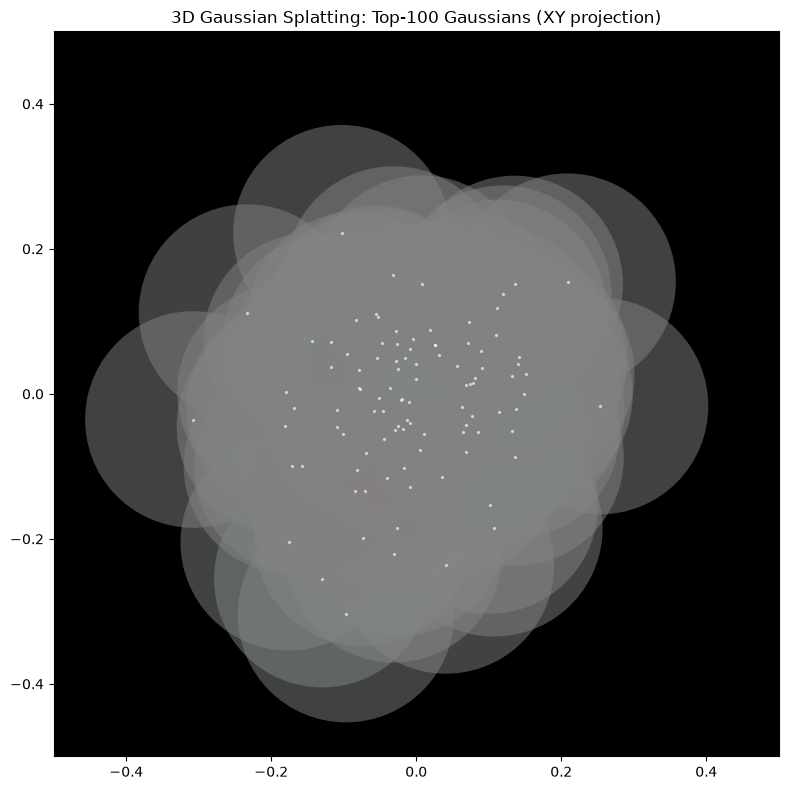

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

class GaussianSplat(nn.Module):
    """
    Learnable 3D Gaussian Splatting scene representation.
    Each Gaussian has: position μ, quaternion q (→R), scale s, opacity α, SH color coeffs.
    """
    def __init__(self, n_gaussians=1000, sh_degree=0):
        super().__init__()
        self.n = n_gaussians
        self.sh_degree = sh_degree
        sh_coeffs = (sh_degree + 1) ** 2
        
        # Learnable parameters
        self.means    = nn.Parameter(torch.randn(n_gaussians, 3) * 0.1)
        self.quats    = nn.Parameter(F.normalize(torch.randn(n_gaussians, 4), dim=-1))  # Quaternion
        self.scales   = nn.Parameter(torch.ones(n_gaussians, 3) * -3.0)   # log scale
        self.opacities= nn.Parameter(torch.zeros(n_gaussians, 1))          # logit opacity
        self.colors   = nn.Parameter(torch.rand(n_gaussians, sh_coeffs, 3) * 0.1)  # SH coefficients
    
    def get_covariance_3d(self):
        """Build 3D covariance matrix from quaternion + scale: Σ = R S S^T R^T."""
        q = F.normalize(self.quats, dim=-1)  # (N, 4)
        s = torch.exp(self.scales)           # (N, 3) positive scale
        
        # Quaternion to rotation matrix
        qw, qx, qy, qz = q[:,0], q[:,1], q[:,2], q[:,3]
        R = torch.stack([
            1-2*(qy**2+qz**2), 2*(qx*qy-qw*qz), 2*(qx*qz+qw*qy),
            2*(qx*qy+qw*qz), 1-2*(qx**2+qz**2), 2*(qy*qz-qw*qx),
            2*(qx*qz-qw*qy), 2*(qy*qz+qw*qx), 1-2*(qx**2+qy**2)
        ], dim=-1).view(-1, 3, 3)  # (N, 3, 3)
        
        # S = diag(s)
        S = torch.diag_embed(s)  # (N, 3, 3)
        
        # Σ = R @ S @ S^T @ R^T
        cov = R @ S @ S.transpose(-1,-2) @ R.transpose(-1,-2)  # (N, 3, 3)
        return cov
    
    def project_to_2d(self, means_3d, cov_3d, view_matrix, proj_matrix, img_size):
        """
        Project 3D Gaussians to 2D screen space.
        Σ_2D = J W Σ W^T J^T
        """
        N = means_3d.shape[0]
        W = view_matrix[:3, :3]  # World-to-camera rotation (3×3)
        
        # Jacobian of projective transform (approximate)
        # For simplicity: use focal_x, focal_y from projection matrix
        fx = proj_matrix[0, 0] * img_size[0] / 2
        fy = proj_matrix[1, 1] * img_size[1] / 2
        
        # Transform means to camera space
        means_cam = (W @ means_3d.T).T  # (N, 3)
        z = means_cam[:, 2].clamp(min=0.1)  # Depth
        
        # Jacobian of perspective projection (per Gaussian)
        J = torch.zeros(N, 2, 3, device=means_3d.device)
        J[:, 0, 0] = fx / z
        J[:, 0, 2] = -fx * means_cam[:, 0] / (z**2)
        J[:, 1, 1] = fy / z
        J[:, 1, 2] = -fy * means_cam[:, 1] / (z**2)
        
        # W matrix (world-to-cam, broadcast)
        W_mat = W.unsqueeze(0).expand(N, -1, -1)  # (N, 3, 3)
        
        # Σ_2D = J @ W @ Σ @ W^T @ J^T
        JW = J @ W_mat  # (N, 2, 3)
        cov_2d = JW @ cov_3d @ JW.transpose(-1,-2)  # (N, 2, 2)
        
        return cov_2d, means_cam
    
    def get_colors(self):
        """Get base color from 0th SH coefficient (dc component)."""
        return torch.sigmoid(self.colors[:, 0, :])  # (N, 3)
    
    def forward(self):
        return {
            'means': self.means,
            'covariances': self.get_covariance_3d(),
            'opacities': torch.sigmoid(self.opacities),
            'colors': self.get_colors()
        }


# Create a scene with some Gaussians
scene = GaussianSplat(n_gaussians=500, sh_degree=0)
params = sum(p.numel() for p in scene.parameters())
print(f"3DGS scene {scene.n} Gaussians, {params:,} parameters")

props = scene()
print(f"Means:       {props['means'].shape}")
print(f"Covariances: {props['covariances'].shape}")
print(f"Opacities:   {props['opacities'].shape}, range: [{props['opacities'].min():.3f}, {props['opacities'].max():.3f}]")
print(f"Colors:      {props['colors'].shape}")

# Visualize Gaussian ellipses projected to 2D (top-down XY view)
means = props['means'].detach().numpy()
covs  = props['covariances'].detach().numpy()
opacs = props['opacities'].detach().squeeze().numpy()
colors_np = props['colors'].detach().numpy()

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_xlim(-0.5, 0.5); ax.set_ylim(-0.5, 0.5)
ax.set_aspect('equal')

# Draw top-K Gaussians by opacity as ellipses
top_k = np.argsort(opacs)[-100:]  # Top 100 by opacity
for i in top_k:
    mu = means[i, :2]          # XY projection
    cov_2d = covs[i, :2, :2]   # 2×2 XY slice
    alpha_val = float(opacs[i])
    c = colors_np[i]
    
    # Eigendecomp for ellipse axes
    try:
        eigvals, eigvecs = np.linalg.eigh(cov_2d)
        eigvals = np.clip(eigvals, 1e-6, None)
        width, height = 2 * np.sqrt(eigvals) * 3  # 3-sigma ellipse
        angle = np.degrees(np.arctan2(eigvecs[1,0], eigvecs[0,0]))
        
        from matplotlib.patches import Ellipse
        ellipse = Ellipse(mu, width, height, angle=angle,
                         alpha=min(alpha_val, 0.7), color=c, linewidth=0)
        ax.add_patch(ellipse)
    except:
        pass

ax.scatter(means[top_k, 0], means[top_k, 1], c='white', s=2, zorder=5, alpha=0.5)
ax.set_title('3D Gaussian Splatting: Top-100 Gaussians (XY projection)', fontsize=12)
ax.set_facecolor('black')
plt.tight_layout(); plt.show()

## BEV Perception for Autonomous Driving

**Bird's Eye View (BEV) representation** projects image features to a top-down 2D map, enabling unified multi-camera fusion and direct 3D reasoning.

### Key Methods

**BEVFormer** (Li et al. 2022):
- **Spatial cross-attention (SCA)**: BEV query grid positions are projected into each camera image via calibration matrices; deformable attention samples image features at 4 reference points per BEV cell
- **Temporal self-attention (TSA)**: Previous BEV features are ego-motion aligned (warp via rotation/translation) and fused with current queries for temporal consistency

**IPM (Inverse Perspective Mapping)**:
- Homography-based BEV lifting; assumes flat ground plane
- Fast but fails for elevated objects (cars, pedestrians)

**Lift-Splat-Shoot** (LSS):
- Predict a depth distribution (softmax over D bins) per pixel → "lift" image features to frustum → "splat" into BEV voxel grid via scatter
- Enables end-to-end differentiable BEV projection

**BEVDet**: Applies LSS for feature lifting + BEV-space data augmentation (flip, scale, rotate)

**PETR** (Position Embedding TRansformer):
- Encode 3D position coordinates into image features; global cross-attention over 3D space (no explicit projection)

**BEVFusion** (MIT/BEVFusion):
- Fuse camera BEV features + LiDAR BEV features via channel concatenation + spatial fusion convolutions
- Handles complementary modalities: camera = semantics, LiDAR = geometry

### Autonomous Driving Datasets

| Dataset | Cameras | Range | Annotations | Size |
|---|---|---|---|---|
| KITTI | 2 stereo | 120m | 2D/3D det, depth | 15K frames |
| nuScenes | 6 (360°) | 100m | 3D det, tracking, seg | 1000 scenes |
| Waymo Open | 5 + 5 LiDAR | 75m | 3D det, tracking | 1000 scenes |
| Argoverse2 | 7 (360°) | 200m | 3D det, motion | 1000 scenes |
| ONCE | 7 | 200m | 3D det | 1M frames |

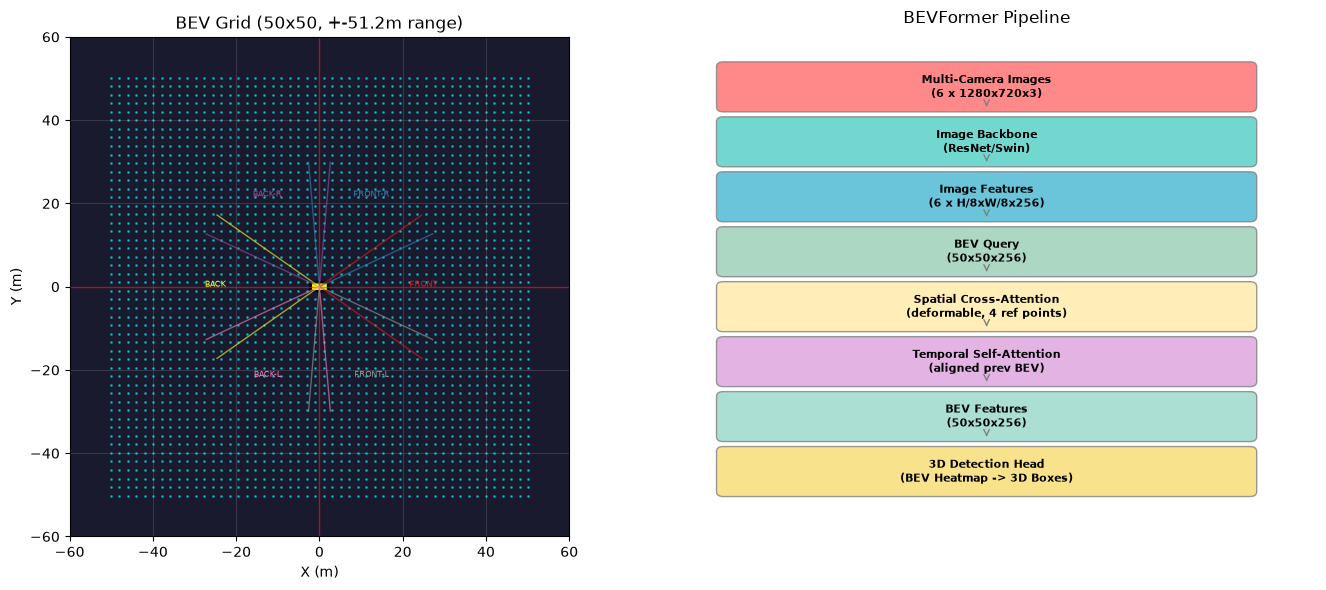

BEVFormer layer Input: torch.Size([1, 2500, 256]), Output: torch.Size([1, 2500, 256])
Layer parameters: 1.05M


In [7]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

class BEVGridGenerator(nn.Module):
    """
    Generate BEV grid query positions for BEVFormer spatial cross-attention.
    Each BEV cell corresponds to a real-world (x, y) location on the ground plane.
    """
    def __init__(self, bev_h=50, bev_w=50, pc_range=[-51.2, -51.2, -5, 51.2, 51.2, 3]):
        super().__init__()
        self.bev_h = bev_h
        self.bev_w = bev_w
        self.pc_range = pc_range  # [x_min, y_min, z_min, x_max, y_max, z_max]
        
        # Generate fixed BEV grid
        xs = torch.linspace(0.5/bev_w, 1-0.5/bev_w, bev_w)
        ys = torch.linspace(0.5/bev_h, 1-0.5/bev_h, bev_h)
        ys, xs = torch.meshgrid(ys, xs, indexing='ij')  # (H, W)
        
        # Scale to real-world coordinates
        x_range = pc_range[3] - pc_range[0]
        y_range = pc_range[4] - pc_range[1]
        self.register_buffer('grid_x', xs * x_range + pc_range[0])  # (H, W)
        self.register_buffer('grid_y', ys * y_range + pc_range[1])  # (H, W)
    
    def project_to_camera(self, lidar2img):
        """
        Project BEV grid positions to image coordinates.
        lidar2img: (N_cams, 4, 4) LiDAR to image projection matrices
        Returns: image_coords (N_cams, H, W, 2) in [0,1]
        """
        H, W = self.bev_h, self.bev_w
        N = lidar2img.shape[0]
        
        # Homogeneous BEV points: (H*W, 4)
        z = torch.zeros_like(self.grid_x)
        ones = torch.ones_like(self.grid_x)
        pts_3d = torch.stack([self.grid_x, self.grid_y, z, ones], dim=-1)  # (H, W, 4)
        pts_3d = pts_3d.view(-1, 4).T  # (4, H*W)
        
        # Project to each camera
        coords_2d = []
        for i in range(N):
            proj = lidar2img[i] @ pts_3d  # (4, H*W) homogeneous image coords
            # Perspective divide
            eps = 1e-6
            u = proj[0] / (proj[2] + eps)
            v = proj[1] / (proj[2] + eps)
            # Normalize to [0,1]
            valid = (proj[2] > 0)  # In front of camera
            u_norm = u.clamp(0, 1280) / 1280
            v_norm = v.clamp(0, 720) / 720
            coords_2d.append(torch.stack([u_norm, v_norm], dim=-1))  # (H*W, 2)
        
        coords_2d = torch.stack(coords_2d, dim=0).view(N, H, W, 2)
        return coords_2d


class BEVFormerEncoderLayer(nn.Module):
    """
    Simplified BEVFormer encoder layer:
    1. Temporal self-attention (TSA): attend to previous BEV features
    2. Spatial cross-attention (SCA): attend to multi-camera image features via deformable attention
    """
    def __init__(self, bev_dims=256, num_heads=8):
        super().__init__()
        self.temporal_attn = nn.MultiheadAttention(bev_dims, num_heads, batch_first=True)
        self.spatial_attn  = nn.MultiheadAttention(bev_dims, num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(bev_dims)
        self.norm2 = nn.LayerNorm(bev_dims)
        self.ffn = nn.Sequential(
            nn.Linear(bev_dims, bev_dims * 4), nn.GELU(),
            nn.Linear(bev_dims * 4, bev_dims)
        )
        self.norm3 = nn.LayerNorm(bev_dims)
    
    def forward(self, bev_query, prev_bev, img_features):
        """
        bev_query:    (B, H*W, D) current BEV query tokens
        prev_bev:     (B, H*W, D) previous timestep BEV (ego-aligned)
        img_features: (B, N_cams*H_img*W_img, D) multi-camera image tokens
        """
        # 1. Temporal self-attention: query attends to previous BEV
        bev = bev_query + self.temporal_attn(bev_query, prev_bev, prev_bev)[0]
        bev = self.norm1(bev)
        
        # 2. Spatial cross-attention: BEV queries attend to image features
        bev = bev + self.spatial_attn(bev, img_features, img_features)[0]
        bev = self.norm2(bev)
        
        # 3. FFN
        bev = bev + self.ffn(bev)
        bev = self.norm3(bev)
        return bev


# Demonstrate BEV grid and camera projection
bev_generator = BEVGridGenerator(bev_h=50, bev_w=50)

# Visualize the BEV grid
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# BEV grid (top-down view)
ax = axes[0]
grid_x = bev_generator.grid_x.numpy()
grid_y = bev_generator.grid_y.numpy()
ax.scatter(grid_x.ravel(), grid_y.ravel(), s=1, c='cyan', alpha=0.5)
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_title('BEV Grid (50x50, +-51.2m range)')
ax.set_aspect('equal')
ax.axhline(0, color='red', linewidth=1, alpha=0.5)
ax.axvline(0, color='red', linewidth=1, alpha=0.5)

# Draw ego vehicle
vehicle = mpatches.FancyBboxPatch((-2, -1), 4, 2, boxstyle="round,pad=0.1",
                                    facecolor='yellow', edgecolor='black', linewidth=2)
ax.add_patch(vehicle)

# Draw camera FOVs (6-camera nuScenes setup)
camera_angles = [0, 60, 120, 180, 240, 300]  # degrees
camera_names = ['FRONT', 'FRONT-R', 'BACK-R', 'BACK', 'BACK-L', 'FRONT-L']
colors_cam = plt.cm.Set1(np.linspace(0, 1, 6))
for angle, name, color in zip(camera_angles, camera_names, colors_cam):
    theta = np.radians(angle)
    fov = np.radians(70)  # 70 deg FOV
    length = 30
    ax.plot([0, length*np.cos(theta-fov/2)], [0, length*np.sin(theta-fov/2)],
            color=color, linewidth=1, alpha=0.6)
    ax.plot([0, length*np.cos(theta+fov/2)], [0, length*np.sin(theta+fov/2)],
            color=color, linewidth=1, alpha=0.6)
    ax.text(25*np.cos(theta), 25*np.sin(theta), name, fontsize=6, ha='center', color=color)
ax.set_xlim(-60, 60); ax.set_ylim(-60, 60)
ax.grid(True, alpha=0.2); ax.set_facecolor('#1a1a2e')

# BEV feature pipeline
ax2 = axes[1]
ax2.axis('off')
pipeline = [
    ('Multi-Camera Images\n(6 x 1280x720x3)', '#FF6B6B'),
    ('Image Backbone\n(ResNet/Swin)', '#4ECDC4'),
    ('Image Features\n(6 x H/8xW/8x256)', '#45B7D1'),
    ('BEV Query\n(50x50x256)', '#96CEB4'),
    ('Spatial Cross-Attention\n(deformable, 4 ref points)', '#FFEAA7'),
    ('Temporal Self-Attention\n(aligned prev BEV)', '#DDA0DD'),
    ('BEV Features\n(50x50x256)', '#98D8C8'),
    ('3D Detection Head\n(BEV Heatmap -> 3D Boxes)', '#F7DC6F'),
]
for i, (step, color) in enumerate(pipeline):
    y = 0.9 - i * 0.11
    ax2.add_patch(mpatches.FancyBboxPatch((0.1, y-0.04), 0.8, 0.08,
                  boxstyle="round,pad=0.01", facecolor=color, edgecolor='gray', alpha=0.8))
    ax2.text(0.5, y, step, ha='center', va='center', fontsize=8, fontweight='bold')
    if i < len(pipeline)-1:
        ax2.annotate('', xy=(0.5, y-0.04), xytext=(0.5, y-0.04+0.01),
                    arrowprops=dict(arrowstyle='->', color='gray'))
ax2.set_title('BEVFormer Pipeline', fontsize=12, pad=10)

plt.tight_layout(); plt.show()

# Test BEVFormer encoder layer
layer = BEVFormerEncoderLayer(bev_dims=256, num_heads=8)
B, H, W, D = 1, 50, 50, 256
bev_query    = torch.randn(B, H*W, D)
prev_bev     = torch.randn(B, H*W, D)
img_features = torch.randn(B, 6*32*56, D)  # 6 cams, H/8=32, W/8=56

out = layer(bev_query, prev_bev, img_features)
print(f"BEVFormer layer Input: {bev_query.shape}, Output: {out.shape}")
params = sum(p.numel() for p in layer.parameters())
print(f"Layer parameters: {params/1e6:.2f}M")

## Implicit Neural Representations

Implicit neural representations (INRs) encode 3D geometry continuously using neural networks as function approximators, replacing explicit meshes or voxels.

### Signed Distance Function (SDF)

$$f(\mathbf{x}): \mathbb{R}^3 \to \mathbb{R}$$

- **Positive** outside the surface, **negative** inside, **zero** on the surface
- Gradient magnitude = 1 (Eikonal constraint): $|\nabla f(\mathbf{x})| = 1$
- Surface: $\mathcal{S} = \{\mathbf{x} \mid f(\mathbf{x}) = 0\}$

### Occupancy Networks (OccNet)

$$f(\mathbf{x}): \mathbb{R}^3 \to [0, 1]$$

- Predicts probability that point **x** is inside the shape
- Conditioned on shape latent code **z** (from encoder)
- Extract surface via Multiresolution IsoSurface Extraction (MISE)

### DeepSDF (Park et al. 2019)

Auto-decoder architecture:
- Learn per-shape latent codes $\mathbf{z}_i$ jointly with network weights
- No encoder: $f_\theta(\mathbf{z}_i, \mathbf{x}) \to \text{SDF value}$
- Generalization via latent space interpolation

### NeuS (Wang et al. 2021)

Neural implicit surface reconstruction from multi-view images:
- Replace NeRF density $\sigma$ with SDF-derived opacity:
  $$\alpha_i = \Phi_s(f(\mathbf{r}(t_i))) - \Phi_s(f(\mathbf{r}(t_{i+1})))$$
  where $\Phi_s$ is the logistic CDF (sigmoid): $\Phi_s(x) = (1 + e^{-sx})^{-1}$
- Unbiased and occlusion-aware weight function
- Recovers smooth, accurate surfaces unlike NeRF

### VolSDF

- Models volume density as Laplace CDF of SDF: $\sigma(\mathbf{x}) = \frac{1}{2\beta} e^{-|f(\mathbf{x})|/\beta}$
- Weight function bounds opacity error by SDF error

### Comparison Table

| Method | Representation | Input | Surface Quality | Speed |
|---|---|---|---|---|
| NeRF | Density field | Multi-view images | Implicit (no surface) | Slow (MLP) |
| NeuS | SDF + volume render | Multi-view images | Excellent | Slow |
| 3DGS | Gaussian primitives | Multi-view images | Good | Real-time |
| OccNet | Occupancy | Point cloud/image | Good | Fast (mesh) |
| DeepSDF | SDF | Point cloud | Excellent | Medium |

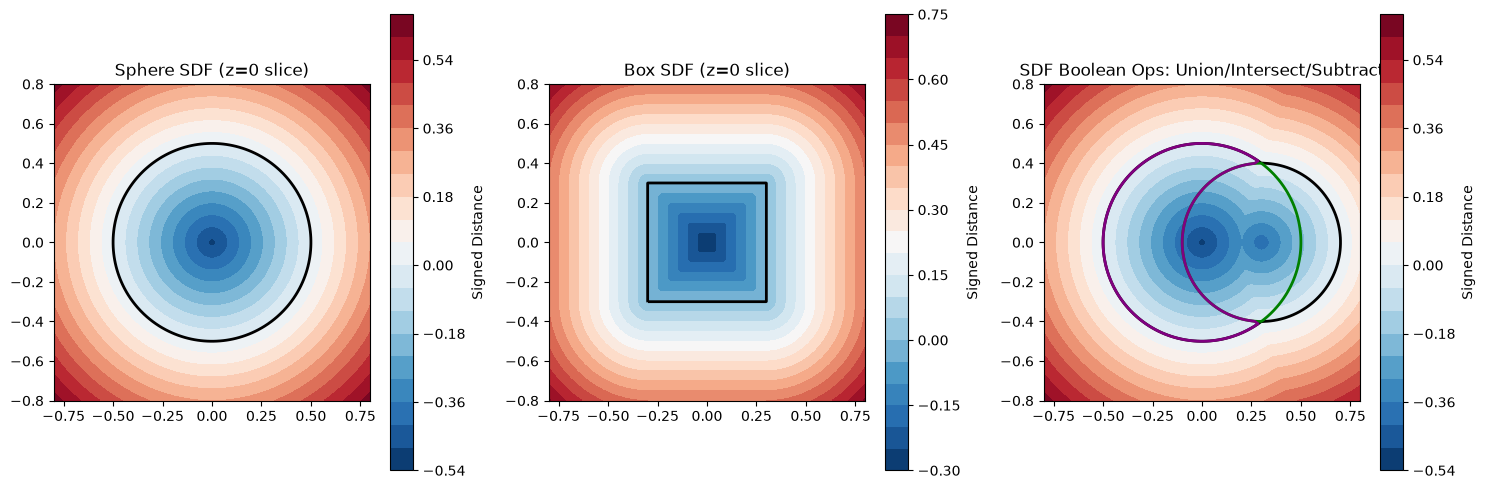

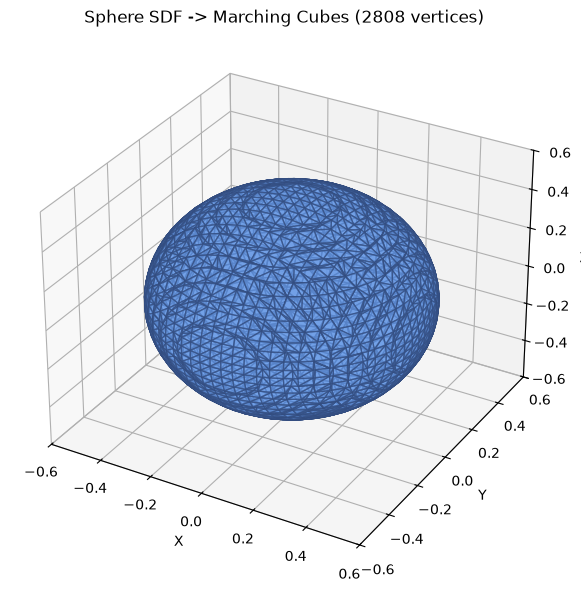

Extracted mesh: 2808 vertices, 5612 faces

SDF Network Input: torch.Size([1000, 3]), Output: torch.Size([1000, 1])
Parameters: 33,665


In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

class SDFNetwork(nn.Module):
    """Simple SDF network: 3D position -> signed distance value."""
    def __init__(self, hidden=128, n_layers=4):
        super().__init__()
        layers = [nn.Linear(3, hidden), nn.Softplus(beta=100)]
        for _ in range(n_layers - 2):
            layers += [nn.Linear(hidden, hidden), nn.Softplus(beta=100)]
        layers += [nn.Linear(hidden, 1)]  # No activation SDF can be negative
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)  # (N, 1)


def sphere_sdf(points, center=torch.zeros(3), radius=0.5):
    """Analytical SDF for a sphere: d = ||x - c|| - r"""
    return (points - center).norm(dim=-1, keepdim=True) - radius


def box_sdf(points, half_extents=torch.tensor([0.3, 0.3, 0.3])):
    """Analytical SDF for an axis-aligned box."""
    q = points.abs() - half_extents
    return (torch.clamp(q, min=0).norm(dim=-1, keepdim=True) +
            torch.clamp(q.max(dim=-1, keepdim=True)[0], max=0))


def marching_cubes_simple(sdf_fn, resolution=30, threshold=0.0, bounds=(-0.8, 0.8)):
    """
    Simple marching cubes via skimage.
    Returns vertices and faces for visualization.
    """
    from skimage import measure
    lin = np.linspace(bounds[0], bounds[1], resolution)
    X, Y, Z = np.meshgrid(lin, lin, lin, indexing='ij')
    pts = torch.tensor(np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=-1), dtype=torch.float32)
    
    with torch.no_grad():
        sdf_vals = sdf_fn(pts).numpy().reshape(resolution, resolution, resolution)
    
    # Marching cubes
    verts, faces, normals, values = measure.marching_cubes(sdf_vals, level=threshold,
                                                             spacing=(lin[1]-lin[0],)*3)
    verts += bounds[0]  # Offset to world coordinates
    return verts, faces


# Visualize SDFs for different shapes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 2D cross-section of SDF (z=0 plane)
lin = np.linspace(-0.8, 0.8, 100)
X, Y = np.meshgrid(lin, lin)
pts_2d = torch.tensor(np.stack([X.ravel(), Y.ravel(), np.zeros(10000)], axis=-1), dtype=torch.float32)

# Sphere SDF
sdf_sphere = sphere_sdf(pts_2d).numpy().reshape(100, 100)
im0 = axes[0].contourf(X, Y, sdf_sphere, levels=20, cmap='RdBu_r')
axes[0].contour(X, Y, sdf_sphere, levels=[0], colors='black', linewidths=2)
axes[0].set_title('Sphere SDF (z=0 slice)'); axes[0].set_aspect('equal')
plt.colorbar(im0, ax=axes[0], label='Signed Distance')

# Box SDF
sdf_box = box_sdf(pts_2d).numpy().reshape(100, 100)
im1 = axes[1].contourf(X, Y, sdf_box, levels=20, cmap='RdBu_r')
axes[1].contour(X, Y, sdf_box, levels=[0], colors='black', linewidths=2)
axes[1].set_title('Box SDF (z=0 slice)'); axes[1].set_aspect('equal')
plt.colorbar(im1, ax=axes[1], label='Signed Distance')

# SDF operations: union, intersection, difference (CSG)
sdf_sphere2 = sphere_sdf(pts_2d, center=torch.tensor([0.3, 0.0, 0.0]), radius=0.4).numpy().reshape(100, 100)
sdf_union = np.minimum(sdf_sphere.reshape(100,100), sdf_sphere2)
sdf_intersect = np.maximum(sdf_sphere.reshape(100,100), sdf_sphere2)
sdf_subtract = np.maximum(sdf_sphere.reshape(100,100), -sdf_sphere2)

im2 = axes[2].contourf(X, Y, sdf_union, levels=20, cmap='RdBu_r')
axes[2].contour(X, Y, sdf_union, levels=[0], colors='black', linewidths=2, label='Union')
axes[2].contour(X, Y, sdf_intersect, levels=[0], colors='green', linewidths=2, label='Intersect')
axes[2].contour(X, Y, sdf_subtract, levels=[0], colors='purple', linewidths=2, label='Subtract')
axes[2].set_title('SDF Boolean Ops: Union/Intersect/Subtract'); axes[2].set_aspect('equal')
plt.colorbar(im2, ax=axes[2], label='Signed Distance')

plt.tight_layout(); plt.show()

# 3D marching cubes
try:
    verts, faces = marching_cubes_simple(sphere_sdf, resolution=40)
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    mesh = Poly3DCollection(verts[faces], alpha=0.7)
    mesh.set_facecolor([0.4, 0.6, 0.9, 0.7])
    mesh.set_edgecolor([0.2, 0.3, 0.5, 0.1])
    ax.add_collection3d(mesh)
    ax.set_xlim(-0.6, 0.6); ax.set_ylim(-0.6, 0.6); ax.set_zlim(-0.6, 0.6)
    ax.set_title(f'Sphere SDF -> Marching Cubes ({len(verts)} vertices)')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.tight_layout(); plt.show()
    print(f"Extracted mesh: {len(verts)} vertices, {len(faces)} faces")
except ImportError:
    print("skimage not installed. Install with: pip install scikit-image")
    print("Marching cubes skipped SDF visualization above is complete.")

# Test SDF network
sdf_net = SDFNetwork(hidden=128, n_layers=4)
pts = torch.randn(1000, 3) * 0.5
sdf_pred = sdf_net(pts)
print(f"\nSDF Network Input: {pts.shape}, Output: {sdf_pred.shape}")
params = sum(p.numel() for p in sdf_net.parameters())
print(f"Parameters: {params:,}")

## 3D Object Detection

3D object detection localizes and classifies objects in 3D space, predicting oriented 3D bounding boxes $(x, y, z, l, w, h, \theta)$.

### PointPillars (Lang et al. 2018)

Divide BEV into vertical pillar cells → PointNet per pillar → scatter to BEV pseudo-image → 2D SSD detection head:

**Pillar feature** (9D per point):
$$(x, y, z, r, x_c, y_c, z_c, x_p, y_p)$$
- $(x,y,z,r)$: coordinates + reflectance
- $(x_c, y_c, z_c)$: offset from pillar center
- $(x_p, y_p)$: offset from point mean within pillar

Very fast: ~62 Hz on GPU.

### CenterPoint (Yin et al. 2021)

Represent objects as **center points** on BEV heatmap (like CenterNet):

**Gaussian heatmap** rendered per object:
$$Y_{xy c} = \exp\!\left(-\frac{(x-\tilde{x})^2+(y-\tilde{y})^2}{2\sigma^2}\right)$$

Prediction heads (separate):
- Heatmap (class probability)
- Height ($z$)
- Size ($l, w, h$)
- Rotation (sin/cos)
- Velocity ($v_x, v_y$) for tracking

Second stage: point-cloud-based refinement via point sampling.

### DETR3D (Wang et al. 2022)

- 3D object queries → project to image plane → bilinear sample image features → cross-attention
- No explicit 3D feature volume needed
- End-to-end trainable, Hungarian matching loss

### VoxelNet (Zhou & Tuzel 2018)

- Voxel Feature Encoding (VFE): PointNet-style per voxel
- 3D sparse convolution backbone
- Region Proposal Network for final detection

### nuScenes Benchmark (NDS / mAP)

| Method | Modality | NDS | mAP | Notes |
|---|---|---|---|---|
| PointPillars | LiDAR | 0.448 | 0.305 | Fast baseline |
| CenterPoint | LiDAR | 0.648 | 0.580 | SOTA LiDAR |
| BEVFormer-L | Camera | 0.569 | 0.481 | Temporal, multi-cam |
| BEVFusion | Cam+LiDAR | 0.712 | 0.656 | Multi-modal SOTA |
| Transfusion | Cam+LiDAR | 0.686 | 0.632 | Transformer fusion |

LiDAR points: 11,500
Non-empty pillars: 9459
BEV grid: 256 x 256
Pillar features shape: torch.Size([9459, 16, 9])
Pillar features after PFN: torch.Size([9459, 64])
BEV pseudo-image: torch.Size([1, 64, 256, 256])


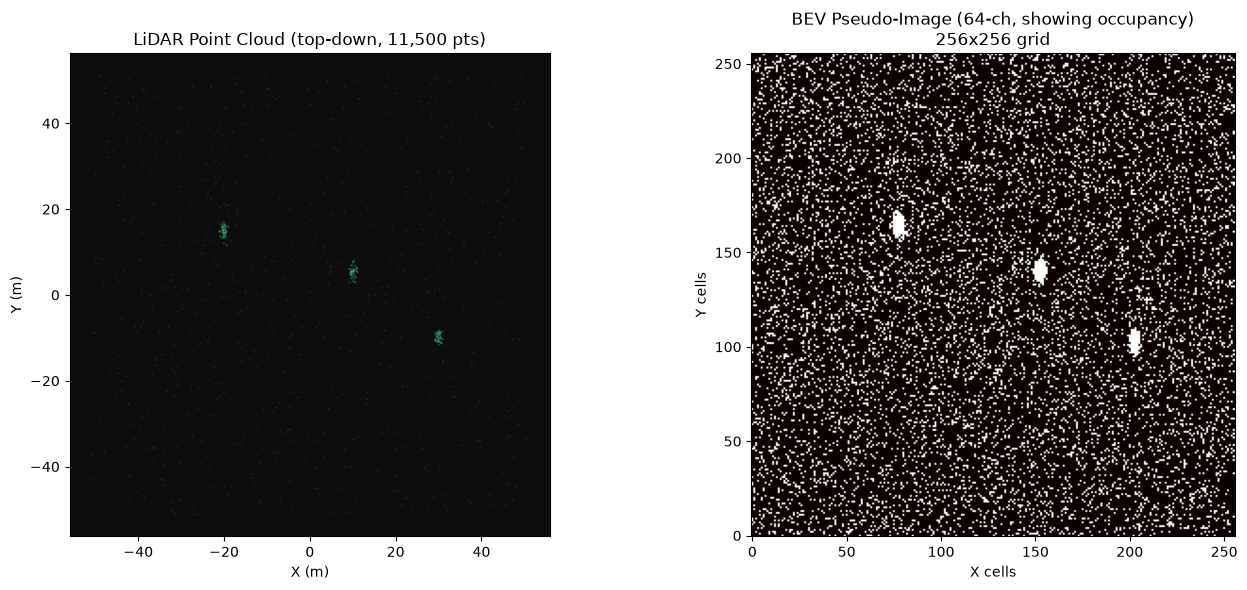

In [9]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

class PillarFeatureNet(nn.Module):
    """
    PointPillars pillar feature extraction.
    Per-pillar: run simplified PointNet on points within each pillar.
    """
    def __init__(self, num_input_features=9, num_filters=64):
        super().__init__()
        # Linear + BN + ReLU per point
        self.linear = nn.Linear(num_input_features, num_filters, bias=False)
        self.bn = nn.BatchNorm1d(num_filters)
    
    def forward(self, pillars, num_points_per_pillar):
        """
        pillars: (N_pillars, max_pts, num_features)
        Returns: pillar_features (N_pillars, num_filters)
        """
        N, P, C = pillars.shape
        x = self.linear(pillars.view(N*P, C))       # (N*P, F)
        x = torch.relu(self.bn(x)).view(N, P, -1)   # (N, P, F)
        # Max pool over points in pillar
        return x.max(dim=1)[0]                       # (N, F)


class PointPillarsScatter(nn.Module):
    """Scatter pillar features into 2D BEV pseudo-image."""
    def __init__(self, num_filters=64, bev_h=496, bev_w=432):
        super().__init__()
        self.bev_h = bev_h
        self.bev_w = bev_w
        self.num_filters = num_filters
    
    def forward(self, pillar_features, coords):
        """
        pillar_features: (N_pillars, F)
        coords: (N_pillars, 2) (row, col) BEV grid indices
        Returns: canvas (1, F, H, W)
        """
        canvas = torch.zeros(1, self.num_filters, self.bev_h, self.bev_w,
                            device=pillar_features.device)
        rows = coords[:, 0].long().clamp(0, self.bev_h-1)
        cols = coords[:, 1].long().clamp(0, self.bev_w-1)
        canvas[0, :, rows, cols] = pillar_features.T
        return canvas


def create_pillars_from_lidar(points, pc_range, pillar_size=(0.16, 0.16), max_pts=32):
    """
    Convert LiDAR point cloud to pillars.
    points: (N, 4) x,y,z,intensity
    Returns: pillars, coords, num_pts_per_pillar
    """
    x_min, y_min, z_min, x_max, y_max, z_max = pc_range
    px, py = pillar_size
    bev_h = int((y_max - y_min) / py)
    bev_w = int((x_max - x_min) / px)
    
    # Filter points in range
    mask = ((points[:,0] >= x_min) & (points[:,0] < x_max) &
            (points[:,1] >= y_min) & (points[:,1] < y_max) &
            (points[:,2] >= z_min) & (points[:,2] < z_max))
    points = points[mask]
    
    # Assign each point to a pillar (grid cell)
    col_idx = ((points[:,0] - x_min) / px).long().clamp(0, bev_w-1)
    row_idx = ((points[:,1] - y_min) / py).long().clamp(0, bev_h-1)
    pillar_idx = row_idx * bev_w + col_idx  # Flat index
    
    # Group points by pillar
    unique_pillars, inverse_idx = torch.unique(pillar_idx, return_inverse=True)
    N_pillars = len(unique_pillars)
    
    # Compute pillar centers
    pillar_rows = (unique_pillars // bev_w).float()
    pillar_cols = (unique_pillars % bev_w).float()
    
    # Build feature matrix: (N_pillars, max_pts, 9)
    pillars_feat = torch.zeros(N_pillars, max_pts, 9)
    num_pts = torch.zeros(N_pillars, dtype=torch.long)
    
    for i, pid in enumerate(unique_pillars):
        mask_p = (pillar_idx == pid)
        pts_p = points[mask_p]
        n = min(len(pts_p), max_pts)
        num_pts[i] = n
        
        center_x = pillar_cols[i] * px + x_min + px/2
        center_y = pillar_rows[i] * py + y_min + py/2
        mean = pts_p[:n, :3].mean(0)
        
        pillars_feat[i, :n, :4] = pts_p[:n, :4]
        pillars_feat[i, :n, 4]  = pts_p[:n, 0] - float(center_x)
        pillars_feat[i, :n, 5]  = pts_p[:n, 1] - float(center_y)
        pillars_feat[i, :n, 6]  = pts_p[:n, 2]
        pillars_feat[i, :n, 7]  = pts_p[:n, 0] - mean[0]
        pillars_feat[i, :n, 8]  = pts_p[:n, 1] - mean[1]
    
    coords = torch.stack([pillar_rows, pillar_cols], dim=-1).long()
    return pillars_feat, coords, num_pts, (bev_h, bev_w)


# Generate synthetic LiDAR point cloud
np.random.seed(42)
N_pts = 20000
pc_range = [-51.2, -51.2, -3.0, 51.2, 51.2, 1.0]

# Ground plane + some objects
ground = np.column_stack([
    np.random.uniform(-51.2, 51.2, N_pts//2),
    np.random.uniform(-51.2, 51.2, N_pts//2),
    np.random.uniform(-3.0, -2.8, N_pts//2),
    np.random.uniform(0.1, 0.5, N_pts//2)
])

# 3 cars (dense clusters)
car_pts = []
for cx, cy in [(10, 5), (-20, 15), (30, -10)]:
    pts = np.random.randn(500, 4) * [0.5, 1.0, 0.3, 0.1] + [cx, cy, -2.0, 0.8]
    car_pts.append(pts)
car_pts = np.vstack(car_pts)

points_np = np.vstack([ground, car_pts])
points_t = torch.tensor(points_np, dtype=torch.float32)

# Create pillars
pillars, coords, num_pts, (bev_h, bev_w) = create_pillars_from_lidar(
    points_t, pc_range, pillar_size=(0.4, 0.4), max_pts=16
)
print(f"LiDAR points: {len(points_t):,}")
print(f"Non-empty pillars: {len(pillars)}")
print(f"BEV grid: {bev_h} x {bev_w}")
print(f"Pillar features shape: {pillars.shape}")

# Extract features
pfn = PillarFeatureNet(num_input_features=9, num_filters=64)
pillar_feat = pfn(pillars, num_pts)
print(f"Pillar features after PFN: {pillar_feat.shape}")

# Scatter to BEV
scatter = PointPillarsScatter(num_filters=64, bev_h=bev_h, bev_w=bev_w)
bev_map = scatter(pillar_feat.detach(), coords)
print(f"BEV pseudo-image: {bev_map.shape}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Point cloud top-down
axes[0].scatter(points_np[::10, 0], points_np[::10, 1], c=points_np[::10, 2],
               cmap='viridis', s=0.5, alpha=0.3)
axes[0].set_title(f'LiDAR Point Cloud (top-down, {len(points_t):,} pts)')
axes[0].set_xlabel('X (m)'); axes[0].set_ylabel('Y (m)')
axes[0].set_aspect('equal'); axes[0].set_facecolor('#0d0d0d')

# BEV pillar occupancy
bev_occupancy = (bev_map[0].detach().norm(dim=0) > 0).numpy()
axes[1].imshow(bev_occupancy, cmap='hot', origin='lower', aspect='equal')
axes[1].set_title(f'BEV Pseudo-Image (64-ch, showing occupancy)\n{bev_h}x{bev_w} grid')
axes[1].set_xlabel('X cells'); axes[1].set_ylabel('Y cells')

plt.tight_layout(); plt.show()

## Depth Estimation Monocular & Stereo

Monocular depth estimation predicts per-pixel depth from a single image an ill-posed problem requiring strong priors.

### Loss Functions

**Scale-invariant loss** (Eigen et al. / MiDaS):
$$\mathcal{L}_{si} = \frac{1}{n}\sum_i d_i^2 - \frac{1}{n^2}\!\left(\sum_i d_i\right)^2, \quad d_i = \log\hat{y}_i - \log y_i$$

Invariant to global scale suitable when absolute depth is unknown.

**Affine-invariant**: MiDaS predicts inverse relative depth; aligned with ground truth via least-squares scale + shift before evaluation.

### Foundation Models

**DPT (Dense Prediction Transformer)**:
- ViT backbone with "Reassemble" and "Fusion" decoder stages
- Reassemble: extract tokens at 4 scales, reshape to feature maps
- Fusion: iterative upsampling + residual convolutions

**Depth Anything V1** (2024):
- Teacher-student: pretrain teacher on labeled data, generate pseudo-labels on 62M unlabeled images
- Semantic-assisted auxiliary task improves fine-grained detail

**Depth Anything V2** (2024):
- Replace unlabeled real data with high-quality synthetic images (Hypersim, Virtual KITTI 2)
- Coarse real-world metric annotations for scale calibration
- Finer granularity, better thin structures, SOTA on all benchmarks

**ZoeDepth**: DPT/BEiT backbone + lightweight metric head; zero-shot metric depth transfer

**UniDepth**: Predicts camera intrinsics + metric depth jointly camera-aware representation

**DepthPro** (Apple 2024): Absolute scale estimation, high-res processing, sharp boundaries

### Benchmarks

| Method | NYUv2 δ1↑ | KITTI δ1↑ | AbsRel↓ | Notes |
|---|---|---|---|---|
| MiDaS v3.1 | 0.892 | 0.962 | 0.050 | Multi-dataset, affine-inv |
| DPT-Large | 0.904 | 0.963 | 0.048 | ViT backbone |
| ZoeDepth-NK | 0.951 | 0.977 | 0.038 | Metric, zero-shot |
| Depth Anything V1 | 0.963 | 0.982 | 0.032 | Large unlabeled data |
| Depth Anything V2 | 0.977 | 0.989 | 0.025 | Synthetic+real, SOTA |
| UniDepth | 0.972 | 0.986 | 0.029 | Camera-aware |
| DepthPro | 0.975 | 0.988 | 0.027 | Sharp boundaries |

=== Depth Estimation APIs ===

--- Depth Anything V2 ---

from transformers import AutoImageProcessor, AutoModelForDepthEstimation
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Depth Anything V2 foundation model for monocular depth
model_id = "depth-anything/Depth-Anything-V2-Large-hf"
processor = AutoImageProcessor.from_pretrained(model_id)
model = AutoModelForDepthEstimation.from_pretrained(model_id)

image = Image.open("scene.jpg")
inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    depth = outputs.predicted_depth  # (1, H, W) relative inverse depth

import torch.nn.functional as F
depth_resized = F.interpolate(
    depth.unsqueeze(1),
    size=image.size[::-1],
    mode="bicubic", align_corners=False
).squeeze()

depth_np = depth_resized.numpy()
depth_norm = (depth_np - depth_np.min()) / (depth_np.max() - depth_np.min())

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1); plt.imshow(i

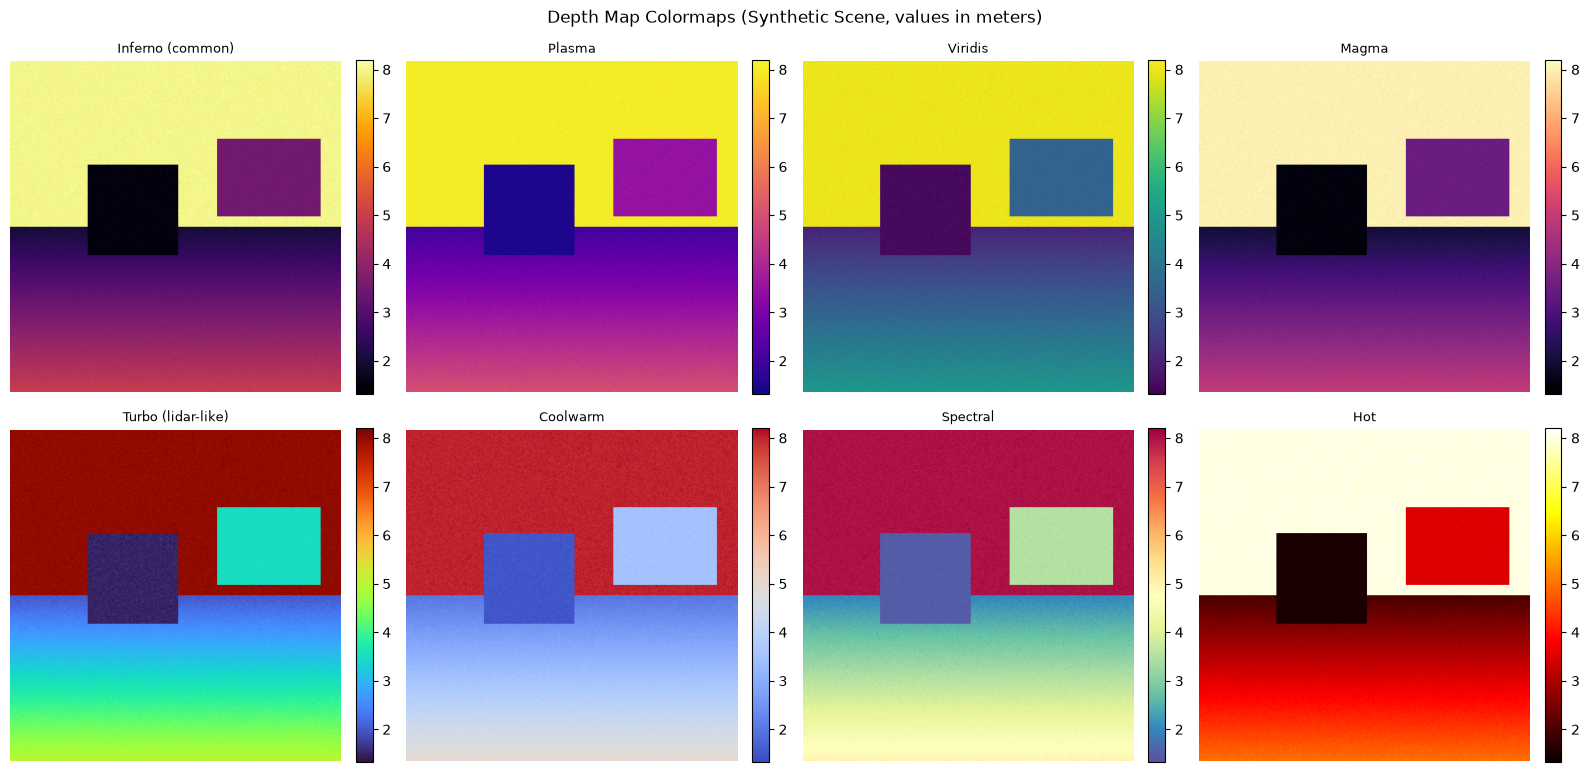


=== Monocular Depth Estimation Benchmarks ===
Method               NYUv2 d1     KITTI d1     AbsRel     Notes
----------------------------------------------------------------------
MiDaS v3.1           0.892        0.962        0.050      Multi-dataset, affine-invariant
DPT-Large            0.904        0.963        0.048      ViT backbone
ZoeDepth-NK          0.951        0.977        0.038      Metric depth, zero-shot
Depth Anything V1    0.963        0.982        0.032      Large-scale unlabeled data
Depth Anything V2    0.977        0.989        0.025      Synthetic + real, SOTA 2024
UniDepth             0.972        0.986        0.029      Camera-aware, joint intrinsics
DepthPro             0.975        0.988        0.027      Sharp boundaries, Apple 2024


In [10]:
# Production usage of Depth Anything V2, MiDaS, and ZoeDepth
# pip install transformers torch torchvision pillow matplotlib

import numpy as np
import matplotlib.pyplot as plt

# -------- Depth Anything V2 (HuggingFace) --------
depth_anything_v2_code = '''
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Depth Anything V2 foundation model for monocular depth
model_id = "depth-anything/Depth-Anything-V2-Large-hf"
processor = AutoImageProcessor.from_pretrained(model_id)
model = AutoModelForDepthEstimation.from_pretrained(model_id)

image = Image.open("scene.jpg")
inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    depth = outputs.predicted_depth  # (1, H, W) relative inverse depth

import torch.nn.functional as F
depth_resized = F.interpolate(
    depth.unsqueeze(1),
    size=image.size[::-1],
    mode="bicubic", align_corners=False
).squeeze()

depth_np = depth_resized.numpy()
depth_norm = (depth_np - depth_np.min()) / (depth_np.max() - depth_np.min())

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1); plt.imshow(image); plt.title("RGB"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(depth_norm, cmap="inferno"); plt.title("Depth Anything V2"); plt.axis("off")
plt.tight_layout(); plt.show()
'''

# -------- MiDaS --------
midas_code = '''
import torch, cv2, numpy as np
import matplotlib.pyplot as plt

midas = torch.hub.load("intel-isl/MiDaS", "DPT_Large")
transforms = torch.hub.load("intel-isl/MiDaS", "transforms").dpt_transform
midas.eval()

img = cv2.cvtColor(cv2.imread("scene.jpg"), cv2.COLOR_BGR2RGB)
input_batch = transforms(img)
with torch.no_grad():
    pred = midas(input_batch)
    pred = torch.nn.functional.interpolate(pred.unsqueeze(1),
              size=img.shape[:2], mode="bicubic").squeeze().numpy()
'''

# -------- ZoeDepth metric depth --------
zoedepth_code = '''
import torch
from PIL import Image

# ZoeDepth metric depth (meters)
repo = "isl-org/ZoeDepth"
model_zoe_n  = torch.hub.load(repo, "ZoeD_N",  pretrained=True)  # NYUv2 indoor
model_zoe_k  = torch.hub.load(repo, "ZoeD_K",  pretrained=True)  # KITTI outdoor
model_zoe_nk = torch.hub.load(repo, "ZoeD_NK", pretrained=True)  # Both

image = Image.open("scene.jpg")
depth_metric = model_zoe_n.infer_pil(image)  # Returns metric depth in meters
print(f"Depth range: {depth_metric.min():.2f}m - {depth_metric.max():.2f}m")
'''

print("=== Depth Estimation APIs ===")
print("\n--- Depth Anything V2 ---")
print(depth_anything_v2_code)
print("\n--- MiDaS ---")
print(midas_code)
print("\n--- ZoeDepth (Metric Depth) ---")
print(zoedepth_code)

# Synthetic depth visualization to show colormaps
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
np.random.seed(42)

# Create synthetic depth map (simulated room)
size = 256
depth_map = np.zeros((size, size))
depth_map[:] = 8.0
for i in range(size//2, size):
    depth_map[i, :] = 2.0 + (i - size//2) / (size//2) * 3.0
depth_map[80:150, 60:130] = 1.5
depth_map[60:120, 160:240] = 3.5
depth_map += np.random.normal(0, 0.05, depth_map.shape)
depth_map = np.clip(depth_map, 0.5, 10.0)

colormaps = ['inferno', 'plasma', 'viridis', 'magma', 'turbo', 'coolwarm', 'Spectral_r', 'hot']
titles = ['Inferno (common)', 'Plasma', 'Viridis', 'Magma', 'Turbo (lidar-like)', 'Coolwarm', 'Spectral', 'Hot']

for i, (cmap, title) in enumerate(zip(colormaps, titles)):
    ax = axes[i//4][i%4]
    im = ax.imshow(depth_map, cmap=cmap)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Depth Map Colormaps (Synthetic Scene, values in meters)', fontsize=12)
plt.tight_layout(); plt.show()

# Print depth estimation benchmark
print("\n=== Monocular Depth Estimation Benchmarks ===")
print(f"{'Method':<20} {'NYUv2 d1':<12} {'KITTI d1':<12} {'AbsRel':<10} {'Notes'}")
print("-"*70)
benchmarks = [
    ("MiDaS v3.1",         "0.892", "0.962", "0.050", "Multi-dataset, affine-invariant"),
    ("DPT-Large",           "0.904", "0.963", "0.048", "ViT backbone"),
    ("ZoeDepth-NK",         "0.951", "0.977", "0.038", "Metric depth, zero-shot"),
    ("Depth Anything V1",   "0.963", "0.982", "0.032", "Large-scale unlabeled data"),
    ("Depth Anything V2",   "0.977", "0.989", "0.025", "Synthetic + real, SOTA 2024"),
    ("UniDepth",            "0.972", "0.986", "0.029", "Camera-aware, joint intrinsics"),
    ("DepthPro",            "0.975", "0.988", "0.027", "Sharp boundaries, Apple 2024"),
]
for method, nyu, kitti, absrel, notes in benchmarks:
    print(f"{method:<20} {nyu:<12} {kitti:<12} {absrel:<10} {notes}")

## Additional Learning Resources

### Original Papers
- [PointNet: Deep Learning on Point Sets](https://arxiv.org/abs/1612.00593) Qi et al. 2017
- [PointNet++: Deep Hierarchical Feature Learning](https://arxiv.org/abs/1706.02413) Qi et al. 2017
- [DGCNN: Dynamic Graph CNN for Learning on Point Clouds](https://arxiv.org/abs/1801.07829) Wang et al. 2019
- [VoteNet: Deep Hough Voting for 3D Object Detection](https://arxiv.org/abs/1904.09664) Qi et al. 2019
- [PointPillars: Fast Encoders for Object Detection from Point Clouds](https://arxiv.org/abs/1812.05784) Lang et al. 2018
- [NeRF: Representing Scenes as Neural Radiance Fields](https://arxiv.org/abs/2003.08934) Mildenhall et al. 2020
- [Instant Neural Graphics Primitives](https://arxiv.org/abs/2201.05989) Müller et al. 2022
- [3D Gaussian Splatting for Real-Time Radiance Field Rendering](https://arxiv.org/abs/2308.04079) Kerbl et al. 2023
- [BEVFormer: Learning Bird's-Eye-View Representation](https://arxiv.org/abs/2203.17270) Li et al. 2022
- [BEVFusion: Multi-Task Multi-Sensor Fusion](https://arxiv.org/abs/2205.13542) Liu et al. 2022
- [NeuS: Learning Neural Implicit Surfaces](https://arxiv.org/abs/2106.10689) Wang et al. 2021
- [DeepSDF: Learning Continuous Signed Distance Functions](https://arxiv.org/abs/1901.05103) Park et al. 2019
- [Mip-NeRF: A Multiscale Representation for Anti-Aliasing](https://arxiv.org/abs/2103.13415) Barron et al. 2021
- [Depth Anything V2](https://arxiv.org/abs/2406.09414) Yang et al. 2024
- [ZoeDepth: Zero-shot Transfer by Combining Relative and Metric Depth](https://arxiv.org/abs/2302.12288) Bhat et al. 2023
- [ORB-SLAM3: An Accurate Open-Source Library for Visual, Visual-Inertial and Multi-Map SLAM](https://arxiv.org/abs/2007.11898) Campos et al. 2021
- [CenterPoint: Center-based 3D Object Detection and Tracking](https://arxiv.org/abs/2006.11275) Yin et al. 2021

### Libraries & Tools
- [Open3D](http://www.open3d.org/) 3D data processing library
- [PyTorch3D](https://pytorch3d.org/) Differentiable 3D deep learning
- [nerfstudio](https://docs.nerf.studio/) NeRF framework
- [gsplat](https://github.com/nerfstudio-project/gsplat) 3D Gaussian Splatting
- [MMDetection3D](https://mmdetection3d.readthedocs.io/) 3D detection framework
- [spconv](https://github.com/traveller59/spconv) Sparse convolutions for 3D
- [OpenPCDet](https://github.com/open-mmlab/OpenPCDet) Point cloud detection

### Courses & Tutorials
- [Stanford CS231A: Computer Vision, From 3D Reconstruction to Recognition](http://web.stanford.edu/class/cs231a/)
- [CVPR 2023 Tutorial: Neural Fields](https://neuralfields.cs.brown.edu/cvpr23)
- [NeRF Explosion 2020](https://dellaert.github.io/NeRF/) Frank Dellaert's NeRF survey
- [3D Gaussian Splatting Tutorial](https://huggingface.co/blog/gaussian-splatting) HuggingFace

Point cloud: 76,800 points from 240x320 depth map
3D bounding box: X=[-4.0, 4.0]m, Y=[-3.0, 2.3]m, Z=[1.4, 8.1]m


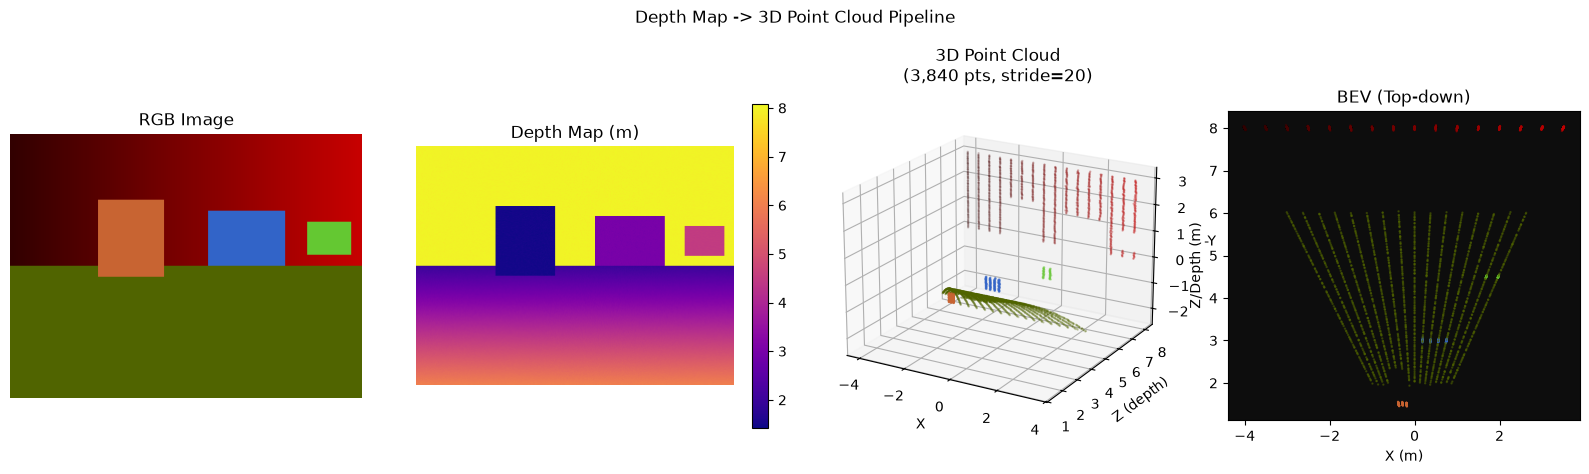


Open3D Integration:

# pip install open3d
import open3d as o3d
import numpy as np

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

pcd_clean, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
pcd_clean.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))

mesh, _ = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd_clean, depth=9)

o3d.visualization.draw_geometries([pcd_clean])
o3d.io.write_point_cloud("scene.ply", pcd_clean)
o3d.io.write_triangle_mesh("scene.obj", mesh)



In [11]:
# Complete production pipeline: Monocular image -> Point Cloud
# Demonstrates integration of depth estimation + 3D reconstruction

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def depth_to_pointcloud(depth_map, rgb_image, fx, fy, cx, cy, max_depth=10.0):
    """
    Back-project depth map to 3D point cloud using pinhole camera model.
    Z = depth, X = (u - cx) * Z / fx, Y = (v - cy) * Z / fy
    """
    H, W = depth_map.shape
    u = np.arange(W)
    v = np.arange(H)
    uu, vv = np.meshgrid(u, v)
    
    Z = depth_map
    X = (uu - cx) * Z / fx
    Y = (vv - cy) * Z / fy
    
    points = np.stack([X, Y, Z], axis=-1).reshape(-1, 3)
    colors = rgb_image.reshape(-1, 3) / 255.0
    
    valid = (Z.ravel() > 0.1) & (Z.ravel() < max_depth)
    return points[valid], colors[valid]


# Simulate a synthetic depth map and RGB image
np.random.seed(42)
H, W = 240, 320

rgb = np.zeros((H, W, 3), dtype=np.uint8)
rgb[:, :, 0] = np.linspace(50, 200, W)
rgb[H//2:, :, 1] = 100
rgb[H//2:, :, 0] = 80
rgb[60:130, 80:140, :]  = [200, 100, 50]
rgb[70:120, 180:250, :] = [50, 100, 200]
rgb[80:110, 270:310, :] = [100, 200, 50]

depth = np.ones((H, W), dtype=np.float32) * 8.0
depth[H//2:, :] = np.linspace(2.0, 6.0, H//2)[:, None]
depth[60:130, 80:140]   = 1.5
depth[70:120, 180:250]  = 3.0
depth[80:110, 270:310]  = 4.5
depth += np.random.normal(0, 0.02, depth.shape)

fx = fy = 320.0
cx, cy = W/2, H/2

points, colors = depth_to_pointcloud(depth, rgb, fx, fy, cx, cy)
print(f"Point cloud: {len(points):,} points from {H}x{W} depth map")
print(f"3D bounding box: X=[{points[:,0].min():.1f}, {points[:,0].max():.1f}]m, "
      f"Y=[{points[:,1].min():.1f}, {points[:,1].max():.1f}]m, "
      f"Z=[{points[:,2].min():.1f}, {points[:,2].max():.1f}]m")

fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(141)
ax1.imshow(rgb)
ax1.set_title('RGB Image'); ax1.axis('off')

ax2 = fig.add_subplot(142)
im = ax2.imshow(depth, cmap='plasma')
ax2.set_title('Depth Map (m)'); ax2.axis('off')
plt.colorbar(im, ax=ax2, fraction=0.046)

ax3 = fig.add_subplot(143, projection='3d')
stride = 20
pts_vis = points[::stride]
col_vis = colors[::stride]
ax3.scatter(pts_vis[:,0], pts_vis[:,2], -pts_vis[:,1],
           c=col_vis, s=0.5, alpha=0.6)
ax3.set_xlabel('X'); ax3.set_ylabel('Z (depth)'); ax3.set_zlabel('-Y')
ax3.set_title(f'3D Point Cloud\n({len(pts_vis):,} pts, stride={stride})')
ax3.view_init(elev=20, azim=-60)

ax4 = fig.add_subplot(144)
ax4.scatter(pts_vis[:,0], pts_vis[:,2], c=col_vis, s=0.5, alpha=0.5)
ax4.set_xlabel('X (m)'); ax4.set_ylabel('Z/Depth (m)')
ax4.set_title('BEV (Top-down)'); ax4.set_aspect('equal')
ax4.set_facecolor('#0d0d0d')

plt.suptitle('Depth Map -> 3D Point Cloud Pipeline', fontsize=12)
plt.tight_layout(); plt.show()

# Open3D integration snippet
open3d_snippet = """
# pip install open3d
import open3d as o3d
import numpy as np

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

pcd_clean, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
pcd_clean.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))

mesh, _ = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd_clean, depth=9)

o3d.visualization.draw_geometries([pcd_clean])
o3d.io.write_point_cloud(\"scene.ply\", pcd_clean)
o3d.io.write_triangle_mesh(\"scene.obj\", mesh)
"""
print("\nOpen3D Integration:")
print(open3d_snippet)